In [1]:
 # Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload the agriculture dataset

from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [3]:
# Load the dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [4]:
# Display first 5 records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
# Check the number of rows and columns

rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 4000
Number of Columns: 28


In [6]:
# Check data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [8]:
# Check missing values

missing = df.isnull().sum()

print("Missing values in each column:\n")
print(missing[missing > 0])

Missing values in each column:

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [9]:
# Calculate missing-value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage.round(2)
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [10]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [11]:
# Check available seasons

print("Seasons available:")
print(df["Season"].unique())

print("\nNumber of records per season:")
print(df["Season"].value_counts())

Seasons available:
['Kharif' 'Rabi' 'Zaid']

Number of records per season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [12]:
# Check crop categories

print("Crops available:")
print(df["Crop"].unique())

print("\nNumber of records per crop:")
print(df["Crop"].value_counts())

Crops available:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Number of records per crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [13]:
# Check geographical coverage

print("Number of unique states:", df["State"].nunique())

print("\nStates:")
print(df["State"].unique())

Number of unique states: 8

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


In [14]:
#  Create a copy of the original dataset

df_clean = df.copy()

print("Working copy created successfully!")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Working copy created successfully!
Rows: 4000
Columns: 28


In [15]:
#  Check missing values

missing = df_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Columns containing missing values:")
print(missing)

Columns containing missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [16]:
#  Fill missing environmental values with median

df_clean["Rainfall_mm"] = df_clean["Rainfall_mm"].fillna(
    df_clean["Rainfall_mm"].median()
)

df_clean["Soil_Moisture_pct"] = df_clean["Soil_Moisture_pct"].fillna(
    df_clean["Soil_Moisture_pct"].median()
)

print("Missing values in Rainfall and Soil Moisture handled.")

Missing values in Rainfall and Soil Moisture handled.


In [17]:
#  Verify relationship between production, area and yield

calculated_yield = (
    df_clean["Production_Tonnes"] /
    df_clean["Farm_Area_Hectares"]
)

difference = (
    df_clean["Yield_Tonnes_Ha"] - calculated_yield
)

print(difference.describe())

count    3968.000000
mean        0.000017
std         0.001070
min        -0.008519
25%        -0.000321
50%         0.000000
75%         0.000313
max         0.010000
dtype: float64


In [18]:
# Fill missing Yield values using Production / Farm Area

missing_yield = df_clean["Yield_Tonnes_Ha"].isnull()

df_clean.loc[missing_yield, "Yield_Tonnes_Ha"] = (
    df_clean.loc[missing_yield, "Production_Tonnes"] /
    df_clean.loc[missing_yield, "Farm_Area_Hectares"]
)

print("Missing Yield values handled.")

Missing Yield values handled.


In [19]:
# Final missing-value check

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Series([], dtype: int64)


In [20]:
# Check duplicate rows

duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [21]:
# Check categorical values

categorical_columns = [
    "Season",
    "Crop",
    "State",
    "Irrigation_Method"
]

for column in categorical_columns:
    print("\n", column)
    print(df_clean[column].value_counts())


 Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

 Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

 State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

 Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [22]:
#  Calculate Profit Margin

df_clean["Profit_Margin_pct"] = (
    df_clean["Profit_INR"] /
    df_clean["Revenue_INR"]
) * 100

print(df_clean[["Profit_INR", "Revenue_INR", "Profit_Margin_pct"]].head())

   Profit_INR  Revenue_INR  Profit_Margin_pct
0      -11852        30810         -38.468030
1     -451950        40401       -1118.660429
2     -124744       190466         -65.494104
3      -95704       200740         -47.675600
4     -144352       193607         -74.559288


In [23]:
# Calculate Revenue per Hectare

df_clean["Revenue_per_Hectare_INR"] = (
    df_clean["Revenue_INR"] /
    df_clean["Farm_Area_Hectares"]
)

print(df_clean[[
    "Revenue_INR",
    "Farm_Area_Hectares",
    "Revenue_per_Hectare_INR"
]].head())

   Revenue_INR  Farm_Area_Hectares  Revenue_per_Hectare_INR
0        30810                0.53             58132.075472
1        40401                6.53              6186.983155
2       190466                4.86             39190.534979
3       200740                4.50             44608.888889
4       193607                4.21             45987.410926


In [24]:
# Final cleaned dataset overview

print("Final Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

Final Dataset Shape: (4000, 30)

Missing Values:
0

Duplicate Rows:
0


In [25]:
# Download the cleaned dataset

df_clean.to_csv("cleaned_seasonal_agriculture_dataset.csv", index=False)

print("Cleaned dataset created successfully!")

Cleaned dataset created successfully!


In [26]:
# Download the cleaned CSV file

from google.colab import files

files.download("cleaned_seasonal_agriculture_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Step 4.1: Distribution of agricultural records by season

season_counts = df_clean["Season"].value_counts()

print("Number of records in each season:")
print(season_counts)

Number of records in each season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


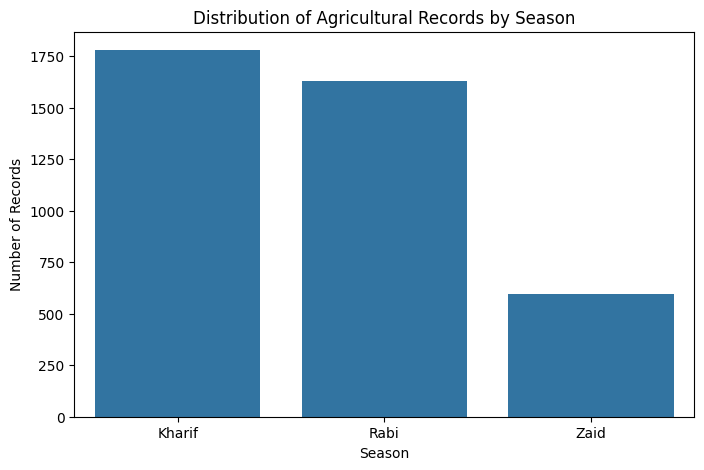

In [28]:
# Bar chart of seasonal records

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Season"
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [29]:
#  Calculate average agricultural performance by season

season_performance = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89
Rabi,5.09,41.49,601526.05,513836.58,87689.47,5.19
Zaid,4.63,38.89,519171.90,543976.73,-24804.82,4.41


In [30]:
# Average yield by season

season_yield = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Season:")
print(season_yield.round(2))

Average Yield by Season:
Season
Kharif    5.63
Rabi      5.09
Zaid      4.63
Name: Yield_Tonnes_Ha, dtype: float64


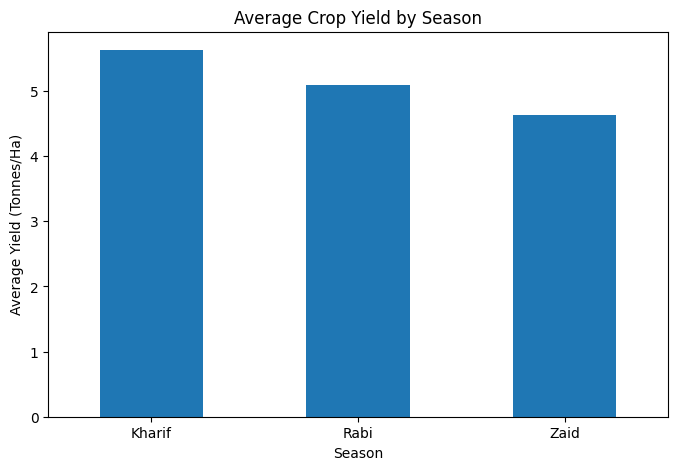

In [31]:
#Visualization
plt.figure(figsize=(8, 5))

season_yield.plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

In [32]:
# Average profit by season

season_profit = (
    df_clean.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Season:")
print(season_profit.round(2))

Average Profit by Season:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64


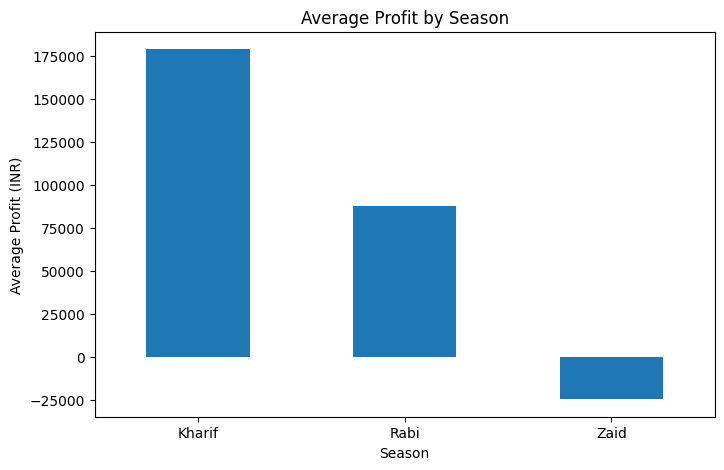

In [33]:
#Visualization
plt.figure(figsize=(8, 5))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

In [34]:
# Average production by season

season_production = (
    df_clean.groupby("Season")["Production_Tonnes"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Production by Season:")
print(season_production.round(2))

Average Production by Season:
Season
Kharif    46.31
Rabi      41.49
Zaid      38.89
Name: Production_Tonnes, dtype: float64


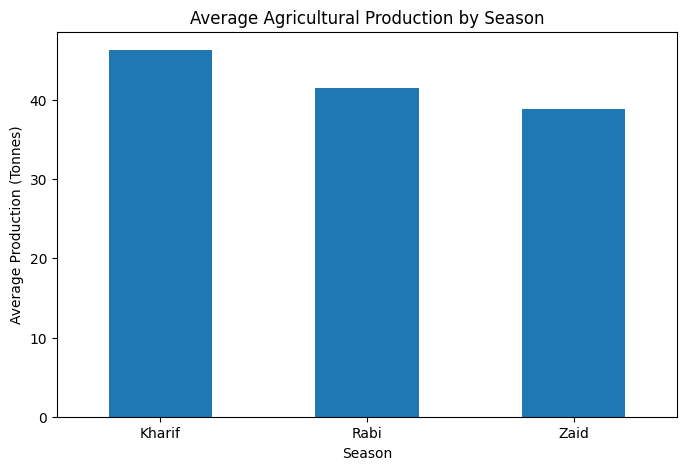

In [35]:
#Visualization
plt.figure(figsize=(8, 5))

season_production.plot(kind="bar")

plt.title("Average Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=0)
plt.show()

In [36]:
# Average water efficiency by season

season_water_efficiency = (
    df_clean.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Efficiency by Season:")
print(season_water_efficiency.round(2))

Average Water Efficiency by Season:
Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


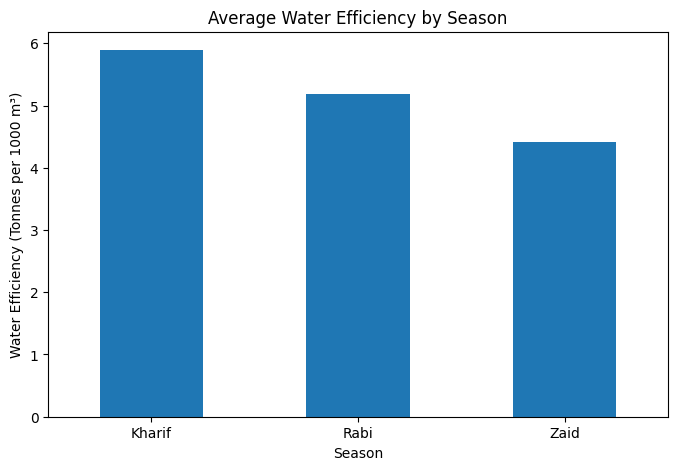

In [37]:
#Visualization
plt.figure(figsize=(8, 5))

season_water_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=0)
plt.show()

In [38]:
#  Seasonal performance summary

season_summary = df_clean.groupby("Season").agg(
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Production_Tonnes=("Production_Tonnes", "mean"),
    Average_Revenue_INR=("Revenue_INR", "mean"),
    Average_Cost_INR=("Total_Cost_INR", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    )
).round(2)

season_summary

,Average_Yield_Tonnes_Ha,Average_Production_Tonnes,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Water_Efficiency
Season,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,5.89
Rabi,5.09,41.49,601526.05,513836.58,87689.47,5.19
Zaid,4.63,38.89,519171.90,543976.73,-24804.82,4.41


In [39]:
# Average rainfall by season

season_rainfall = (
    df_clean.groupby("Season")["Rainfall_mm"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Rainfall by Season:")
print(season_rainfall.round(2))

Average Rainfall by Season:
Season
Kharif    849.20
Rabi      437.62
Zaid      304.65
Name: Rainfall_mm, dtype: float64


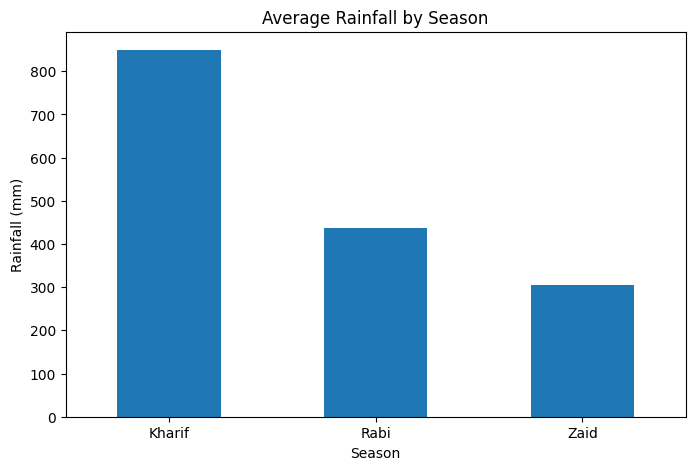

In [40]:
#Visualization
plt.figure(figsize=(8, 5))

season_rainfall.plot(kind="bar")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)

plt.show()

In [41]:
# Average temperature by season

season_temperature = (
    df_clean.groupby("Season")["Avg_Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Temperature by Season:")
print(season_temperature.round(2))

Average Temperature by Season:
Season
Zaid      31.04
Kharif    28.45
Rabi      23.49
Name: Avg_Temperature_C, dtype: float64


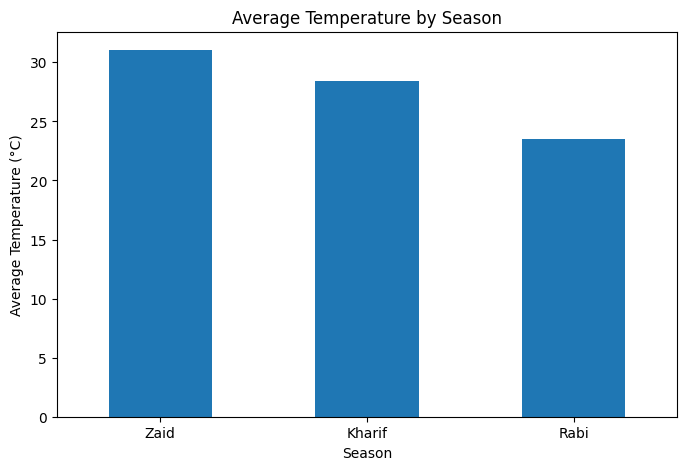

In [42]:
#Visualization
plt.figure(figsize=(8, 5))

season_temperature.plot(kind="bar")

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=0)

plt.show()

In [43]:
# Average humidity by season

season_humidity = (
    df_clean.groupby("Season")["Humidity_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Humidity by Season:")
print(season_humidity.round(2))

Average Humidity by Season:
Season
Kharif    71.81
Rabi      57.89
Zaid      52.01
Name: Humidity_pct, dtype: float64


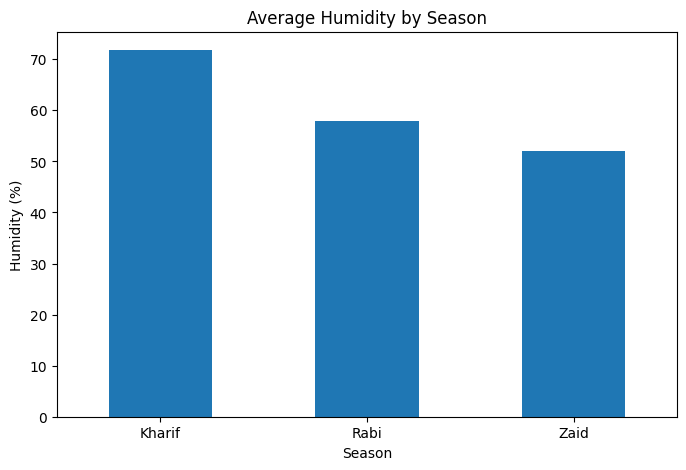

In [44]:
#Visualization
plt.figure(figsize=(8, 5))

season_humidity.plot(kind="bar")

plt.title("Average Humidity by Season")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=0)

plt.show()

In [45]:
# Average soil moisture by season

season_soil_moisture = (
    df_clean.groupby("Season")["Soil_Moisture_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Soil Moisture by Season:")
print(season_soil_moisture.round(2))

Average Soil Moisture by Season:
Season
Kharif    31.15
Rabi      24.07
Zaid      19.28
Name: Soil_Moisture_pct, dtype: float64


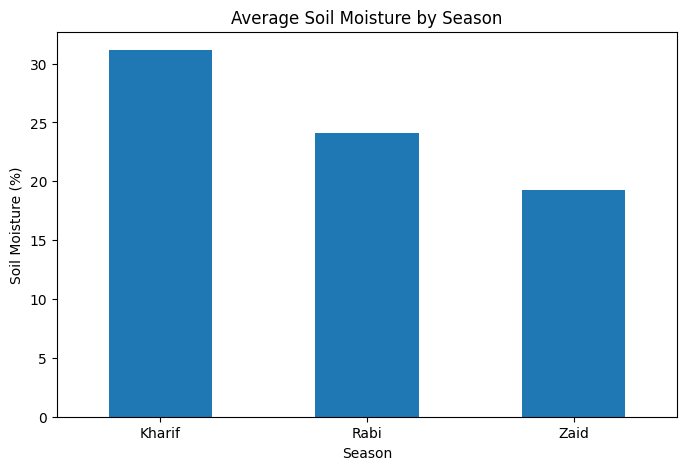

In [46]:
#Visualization
plt.figure(figsize=(8, 5))

season_soil_moisture.plot(kind="bar")

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")
plt.xticks(rotation=0)

plt.show()

In [47]:
# Average sunlight hours by season

season_sunlight = (
    df_clean.groupby("Season")["Sunlight_Hours_Day"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Sunlight Hours by Season:")
print(season_sunlight.round(2))

Average Sunlight Hours by Season:
Season
Zaid      8.18
Rabi      7.59
Kharif    6.79
Name: Sunlight_Hours_Day, dtype: float64


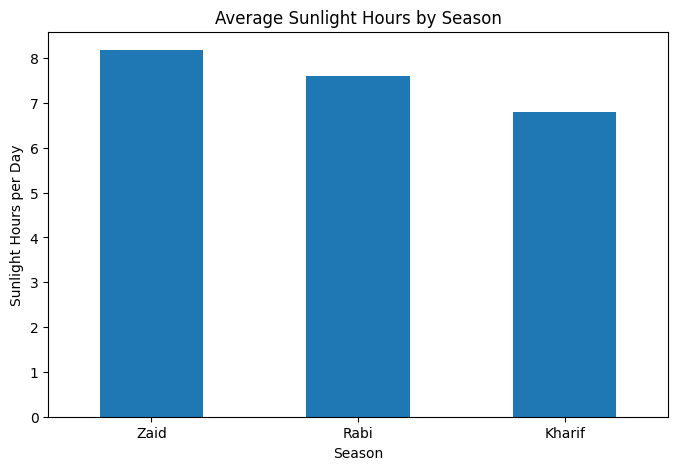

In [48]:
#Visualization
plt.figure(figsize=(8, 5))

season_sunlight.plot(kind="bar")

plt.title("Average Sunlight Hours by Season")
plt.xlabel("Season")
plt.ylabel("Sunlight Hours per Day")
plt.xticks(rotation=0)

plt.show()

In [49]:
# Environmental conditions by season

environment_summary = df_clean.groupby("Season").agg(
    Average_Rainfall_mm=("Rainfall_mm", "mean"),
    Average_Temperature_C=("Avg_Temperature_C", "mean"),
    Average_Humidity_pct=("Humidity_pct", "mean"),
    Average_Sunlight_Hours=("Sunlight_Hours_Day", "mean"),
    Average_Soil_Moisture_pct=("Soil_Moisture_pct", "mean")
).round(2)

environment_summary

,Average_Rainfall_mm,Average_Temperature_C,Average_Humidity_pct,Average_Sunlight_Hours,Average_Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


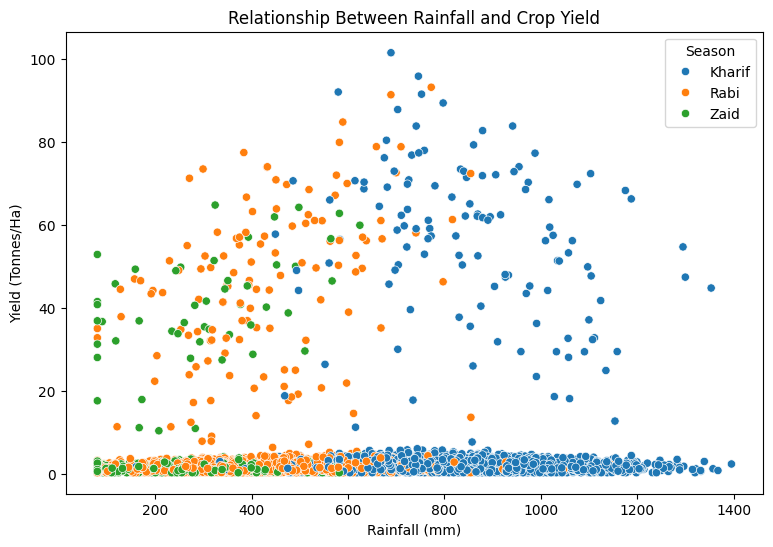

In [50]:
# Rainfall vs Yield
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [51]:
# Calculate correlation between rainfall and yield

rainfall_yield_corr = df_clean[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.029113
Yield_Tonnes_Ha,0.029113,1.000000


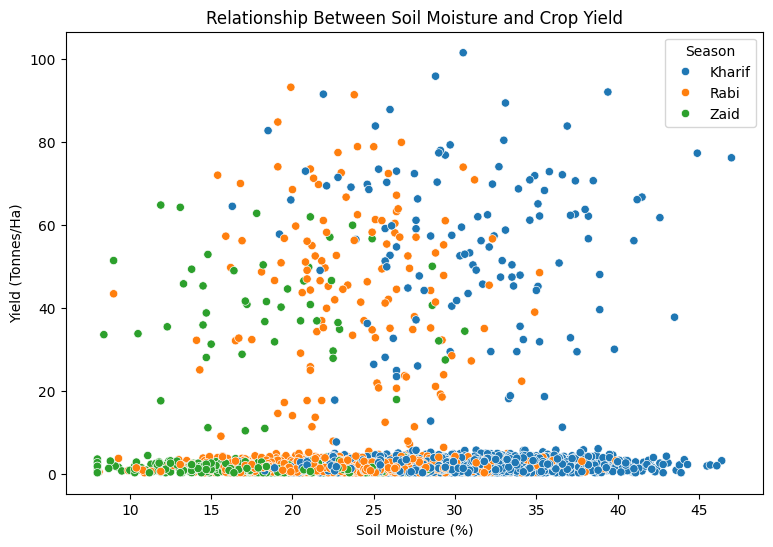

In [52]:
# Soil Moisture vs Yield
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Soil Moisture and Crop Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [54]:
# Soil Moisture-Yield Correlation
soil_yield_corr = df_clean[
    "Soil_Moisture_pct"
].corr(
    df_clean["Yield_Tonnes_Ha"]
)

print("Soil Moisture-Yield Correlation:",
      round(soil_yield_corr, 3))

Soil Moisture-Yield Correlation: 0.01


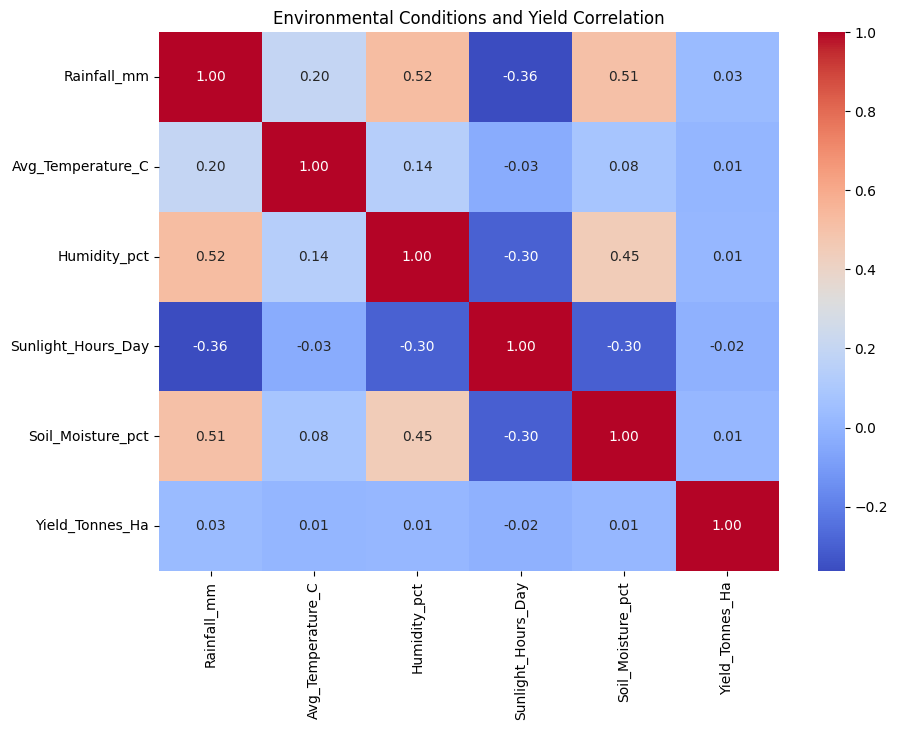

In [55]:
# Environmental and yield correlation matrix

environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

correlation_matrix = df_clean[
    environmental_columns
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Environmental Conditions and Yield Correlation")

plt.show()

In [56]:
# Number of records for each crop

crop_counts = df_clean["Crop"].value_counts()

print("Number of records for each crop:")
print(crop_counts)

Number of records for each crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


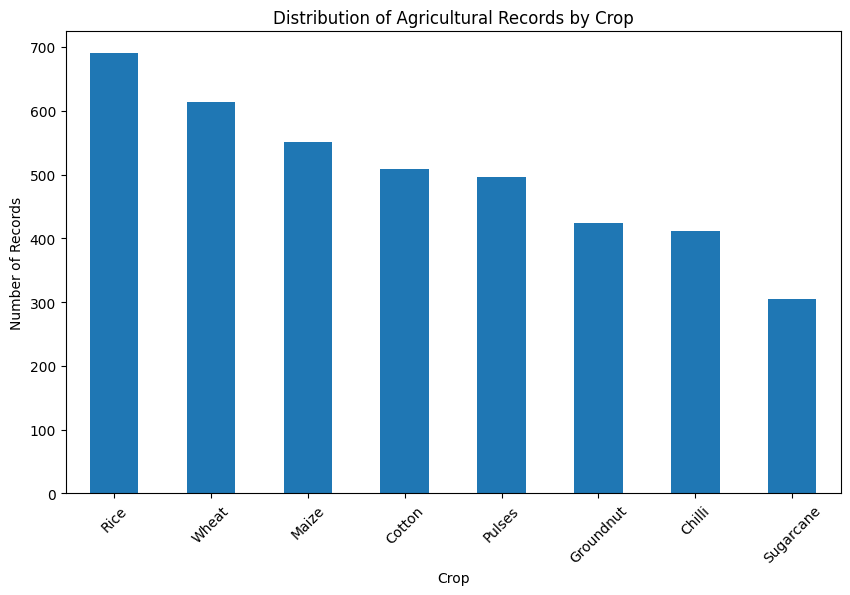

In [57]:
#Visualization
plt.figure(figsize=(10, 6))

crop_counts.plot(kind="bar")

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()


In [58]:
# Average yield for each crop

crop_yield = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Crop:")
print(crop_yield.round(2))

Average Yield by Crop:
Crop
Sugarcane    46.93
Maize         2.71
Rice          2.44
Wheat         2.11
Chilli        1.54
Groundnut     1.32
Cotton        1.22
Pulses        0.92
Name: Yield_Tonnes_Ha, dtype: float64


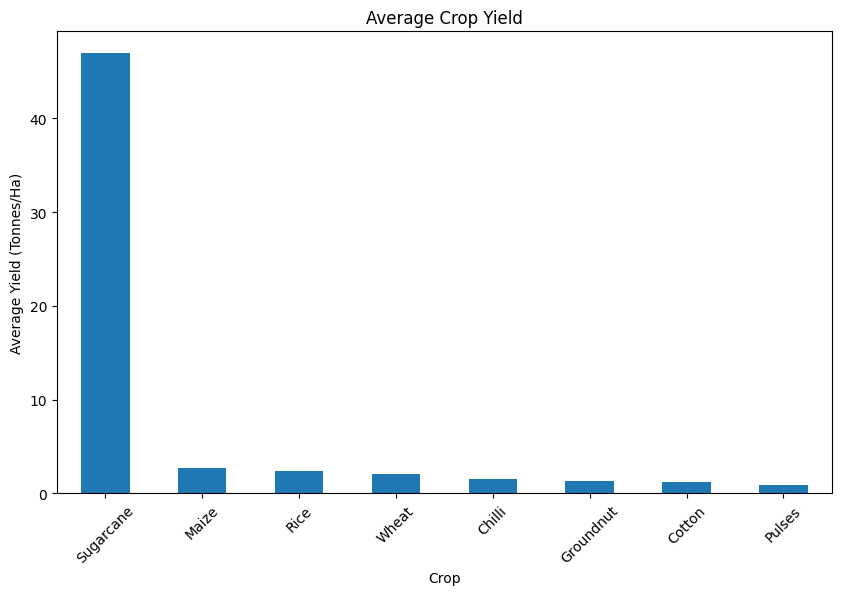

In [59]:
#Visualization
plt.figure(figsize=(10, 6))

crop_yield.plot(kind="bar")

plt.title("Average Crop Yield")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

In [60]:
# Average profit for each crop

crop_profit = (
    df_clean.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Crop:")
print(crop_profit.round(2))

Average Profit by Crop:
Crop
Sugarcane    817187.99
Chilli       750878.34
Cotton       124546.92
Groundnut     44858.12
Pulses        -4238.05
Maize        -83978.33
Rice        -102213.50
Wheat       -123398.34
Name: Profit_INR, dtype: float64


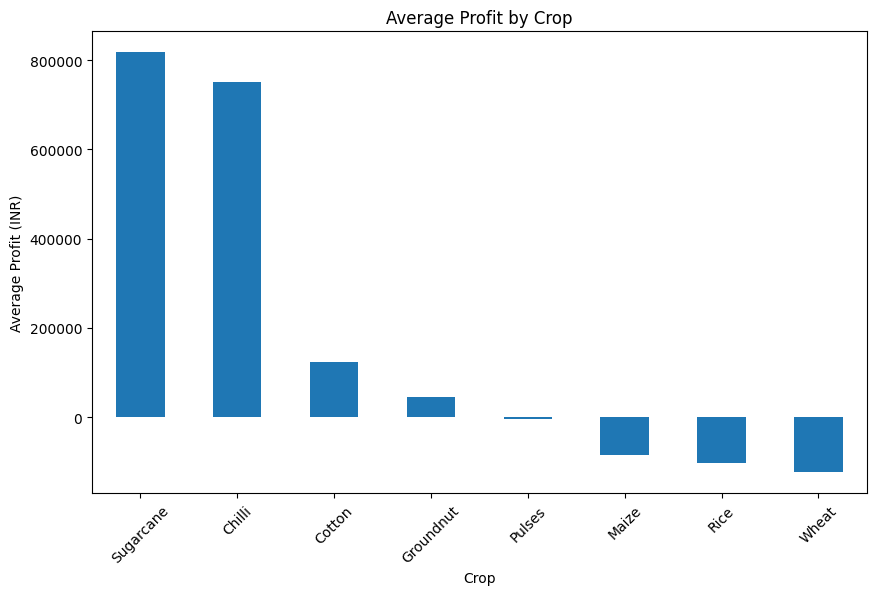

In [61]:
#Visualization
plt.figure(figsize=(10, 6))

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [62]:
# Average profit for each crop

crop_profit = (
    df_clean.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Crop:")
print(crop_profit.round(2))

Average Profit by Crop:
Crop
Sugarcane    817187.99
Chilli       750878.34
Cotton       124546.92
Groundnut     44858.12
Pulses        -4238.05
Maize        -83978.33
Rice        -102213.50
Wheat       -123398.34
Name: Profit_INR, dtype: float64


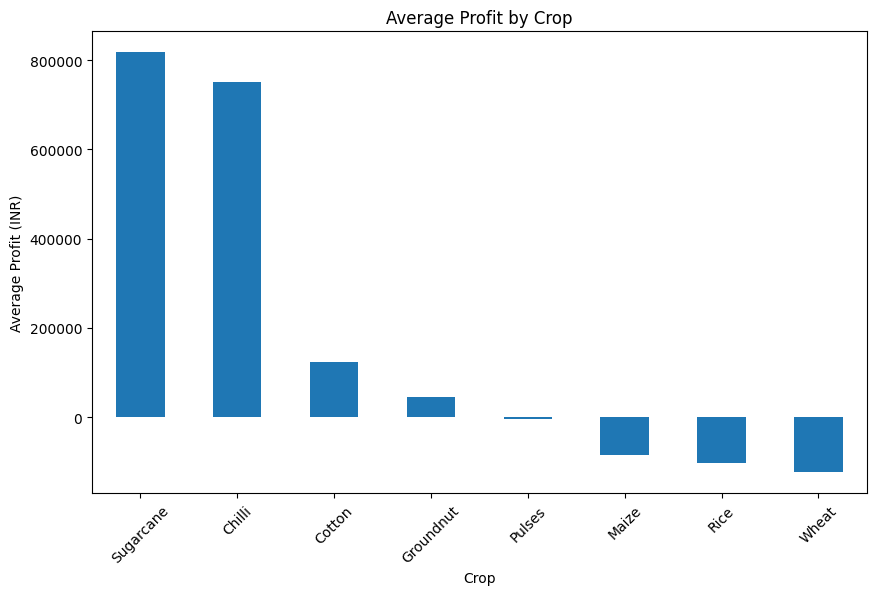

In [63]:
#Visualization
plt.figure(figsize=(10, 6))

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [64]:
# Average yield by crop and season

crop_season_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.94
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.28
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.95,38.42
Wheat,2.25,2.06,1.75


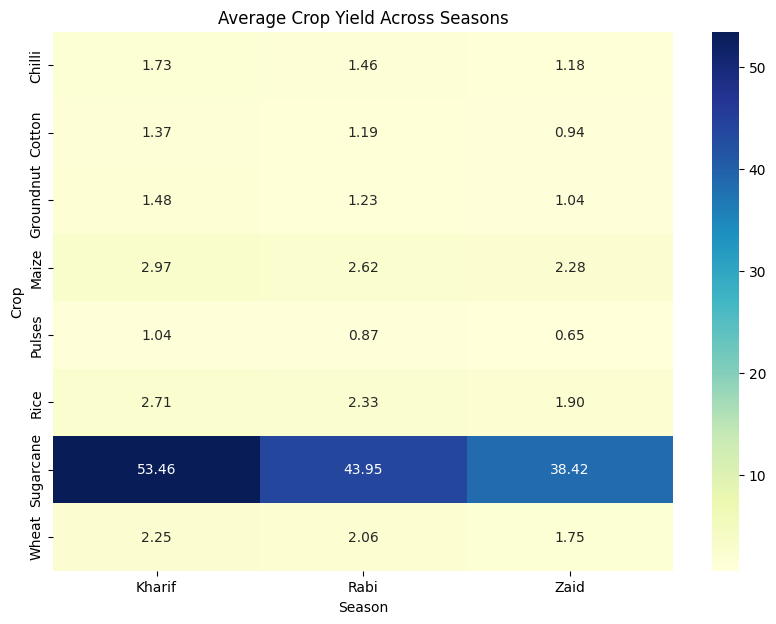

In [65]:
#Viusualization
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [66]:
# Find the highest-yielding crop in each season

best_crop_by_season = (
    df_clean.groupby(["Season", "Crop"])["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
)

best_crop_by_season = best_crop_by_season.loc[
    best_crop_by_season.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
]

best_crop_by_season = best_crop_by_season.sort_values("Season")

print("Highest-yielding crop in each season:")
print(best_crop_by_season)

Highest-yielding crop in each season:
    Season       Crop  Yield_Tonnes_Ha
6   Kharif  Sugarcane        53.459120
14    Rabi  Sugarcane        43.954495
22    Zaid  Sugarcane        38.423922


In [67]:
# Average profit by crop and season

crop_season_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


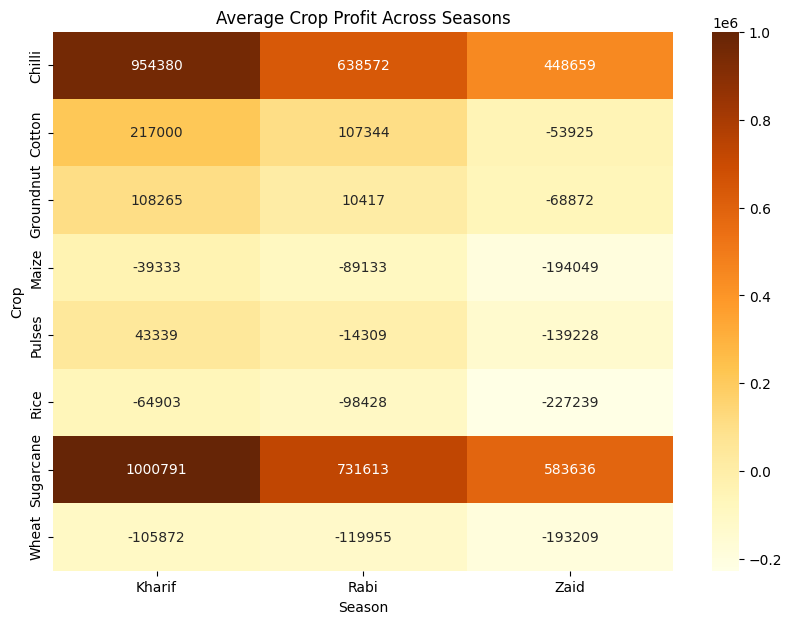

In [68]:
#Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=".0f",
    cmap="YlOrBr"
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [69]:
# Crop and season performance summary

crop_season_summary = df_clean.groupby(
    ["Season", "Crop"]
).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    )
).round(2)

crop_season_summary

Average_Yield  Average_Production  Average_Profit  \
Season Crop                                                           
Kharif Chilli              1.73               14.46       954380.42   
       Cotton              1.37               10.41       216999.55   
       Groundnut           1.48               10.49       108265.44   
       Maize               2.97               23.35       -39332.67   
       Pulses              1.04                8.29        43338.90   
       Rice                2.71               22.45       -64903.40   
       Sugarcane          53.46              446.07      1000790.81   
       Wheat               2.25               18.31      -105871.87   
Rabi   Chilli              1.46               10.97       638572.50   
       Cotton              1.19                9.44       107343.59   
       Groundnut           1.23                9.06        10416.54   
       Maize               2.62               21.59       -89133.40   
       Pulses              0.87                7.20       -14309.14   
       Rice                2.33               17.22       -98427.87   
       Sugarcane          43.95              365.26       731612.86   
       Wheat               2.06               16.07      -119954.57   
Zaid   Chilli              1.18                9.98       448659.09   
       Cotton              0.94                6.93       -53925.34   
       Groundnut           1.04                8.62       -68872.50   
       Maize               2.28               17.94      -194049.17   
       Pulses              0.65                4.94      -139227.81   
       Rice                1.90               15.11      -227239.34   
       Sugarcane          38.42              329.56       583635.80   
       Wheat               1.75               14.06      -193208.95   

                  Average_Water_Efficiency  
Season Crop                                 
Kharif Chilli                         3.26  
       Cotton                         2.13  
       Groundnut                      3.58  
       Maize                          6.05  
       Pulses                         3.35  
       Rice                           2.17  
       Sugarcane                     36.00  
       Wheat                          4.76  
Rabi   Chilli                         2.89  
       Cotton                         1.94  
       Groundnut                      2.90  
       Maize                          5.46  
       Pulses                         2.70  
       Rice                           1.84  
       Sugarcane                     27.92  
       Wheat                          4.69  
Zaid   Chilli                         2.20  
       Cotton                         1.49  
       Groundnut                      2.47  
       Maize                          4.75  
       Pulses                         1.95  
       Rice                           1.53  
       Sugarcane                     23.39  
       Wheat                          4.02

In [70]:
# Step 7.1: Distribution of irrigation methods

irrigation_counts = df_clean["Irrigation_Method"].value_counts()

print("Number of farms using each irrigation method:")
print(irrigation_counts)

Number of farms using each irrigation method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


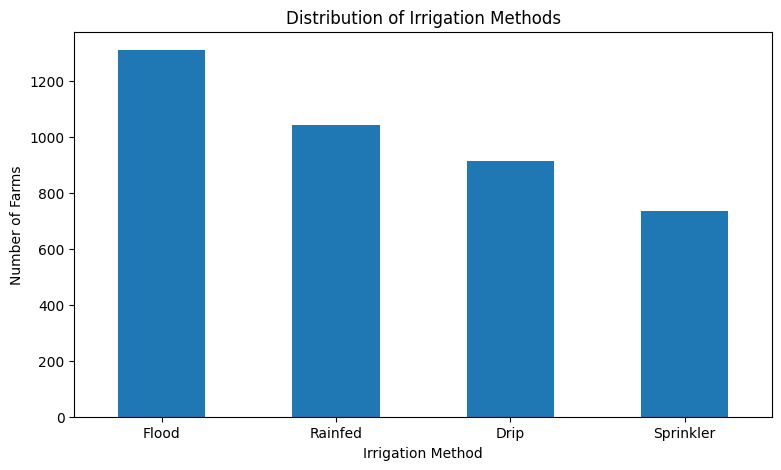

In [71]:
#Visualization
plt.figure(figsize=(9, 5))

irrigation_counts.plot(kind="bar")

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)

plt.show()

In [72]:
# Average water usage by irrigation method

water_by_irrigation = (
    df_clean.groupby("Irrigation_Method")["Water_Used_m3"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Usage by Irrigation Method:")
print(water_by_irrigation.round(2))

Average Water Usage by Irrigation Method:
Irrigation_Method
Flood        8026.47
Sprinkler    6208.26
Drip         5918.75
Rainfed      3549.55
Name: Water_Used_m3, dtype: float64


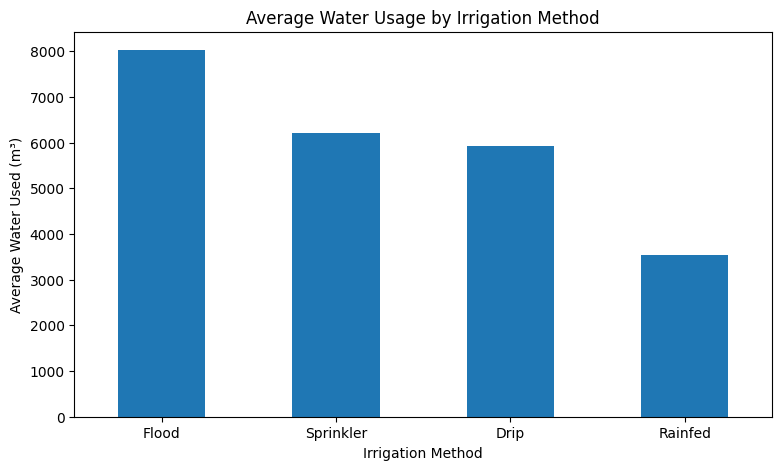

In [73]:
#Visualization
plt.figure(figsize=(9, 5))

water_by_irrigation.plot(kind="bar")

plt.title("Average Water Usage by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=0)

plt.show()

In [74]:
# Average water efficiency by irrigation method

efficiency_by_irrigation = (
    df_clean.groupby("Irrigation_Method")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Efficiency:")
print(efficiency_by_irrigation.round(2))

Average Water Efficiency:
Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


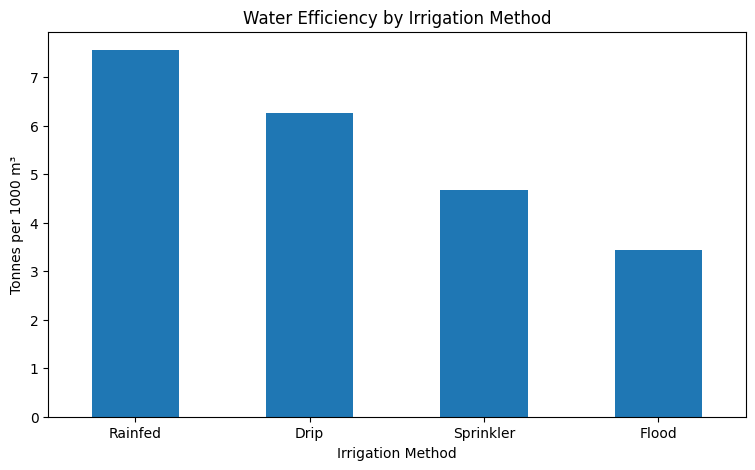

In [75]:
#Visualization
plt.figure(figsize=(9, 5))

efficiency_by_irrigation.plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=0)

plt.show()

In [76]:
# Average yield by irrigation method

yield_by_irrigation = (
    df_clean.groupby("Irrigation_Method")[
        "Yield_Tonnes_Ha"
    ]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Irrigation Method:")
print(yield_by_irrigation.round(2))

Average Yield by Irrigation Method:
Irrigation_Method
Drip         6.68
Sprinkler    5.16
Flood        4.86
Rainfed      4.60
Name: Yield_Tonnes_Ha, dtype: float64


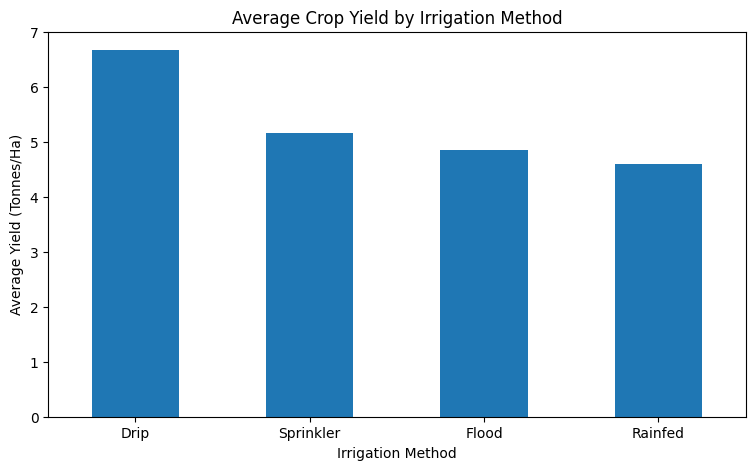

In [77]:
#Visualization
plt.figure(figsize=(9, 5))

yield_by_irrigation.plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.show()

In [78]:
# Average fertilizer usage by season

fertilizer_by_season = (
    df_clean.groupby("Season")["Fertilizer_kg_ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Fertilizer Usage by Season:")
print(fertilizer_by_season.round(2))

Average Fertilizer Usage by Season:
Season
Kharif    187.08
Rabi      185.41
Zaid      184.64
Name: Fertilizer_kg_ha, dtype: float64


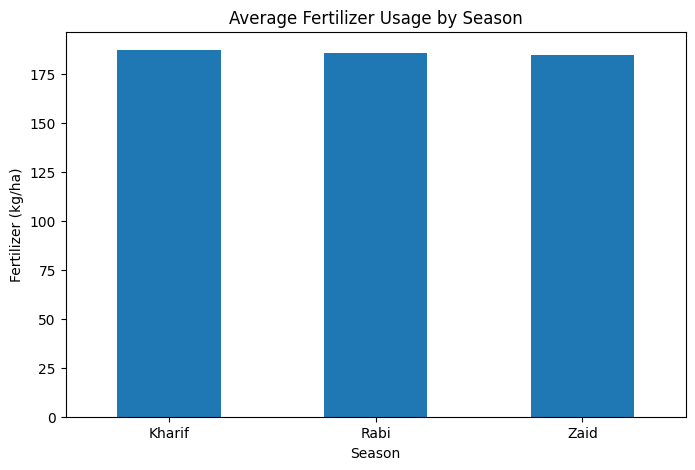

In [79]:
#Visualization
plt.figure(figsize=(8, 5))

fertilizer_by_season.plot(kind="bar")

plt.title("Average Fertilizer Usage by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")
plt.xticks(rotation=0)

plt.show()

In [80]:
# Average pesticide usage by season

pesticide_by_season = (
    df_clean.groupby("Season")["Pesticide_Litre_ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Pesticide Usage by Season:")
print(pesticide_by_season.round(2))

Average Pesticide Usage by Season:
Season
Zaid      5.17
Kharif    5.08
Rabi      5.02
Name: Pesticide_Litre_ha, dtype: float64


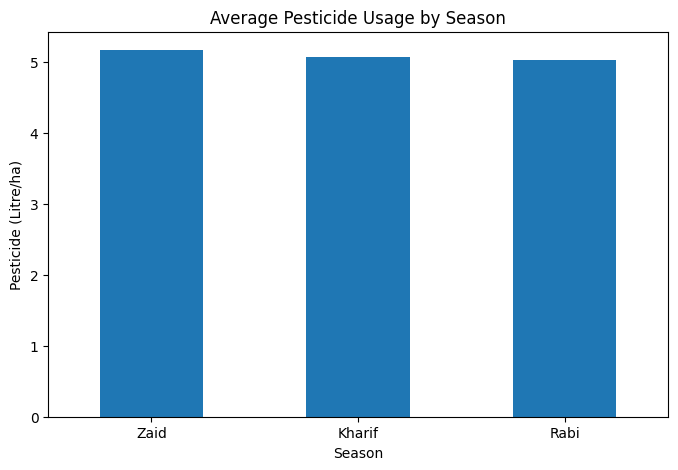

In [81]:
#Visualization
plt.figure(figsize=(8, 5))

pesticide_by_season.plot(kind="bar")

plt.title("Average Pesticide Usage by Season")
plt.xlabel("Season")
plt.ylabel("Pesticide (Litre/ha)")
plt.xticks(rotation=0)

plt.show()

In [82]:
# Resource usage by season

resource_summary = df_clean.groupby("Season").agg(
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Average_Pesticide_Litre_ha=("Pesticide_Litre_ha", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    )
).round(2)

resource_summary

,Average_Water_Used_m3,Average_Fertilizer_kg_ha,Average_Pesticide_Litre_ha,Average_Water_Efficiency
Season,,,,
Kharif,6102.20,187.08,5.08,5.89
Rabi,5846.99,185.41,5.02,5.19
Zaid,6419.89,184.64,5.17,4.41


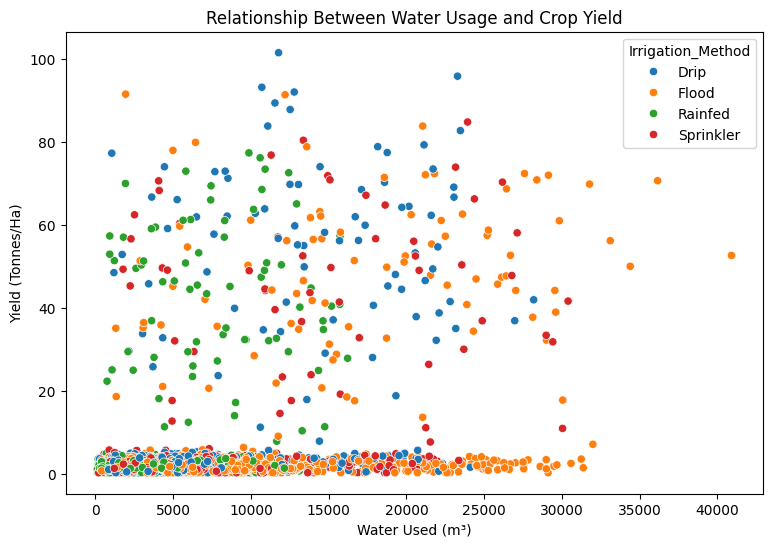

In [83]:
#Water Usage vs Yield
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method"
)

plt.title("Relationship Between Water Usage and Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [84]:
# Correlation between water usage and yield

water_yield_corr = df_clean[
    "Water_Used_m3"
].corr(
    df_clean["Yield_Tonnes_Ha"]
)

print(
    "Water Usage-Yield Correlation:",
    round(water_yield_corr, 3)
)

Water Usage-Yield Correlation: 0.387


In [85]:
# Average water efficiency by season and irrigation method

irrigation_season_efficiency = df_clean.pivot_table(
    values="Water_Efficiency_t_per_1000m3",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
).round(2)

irrigation_season_efficiency

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


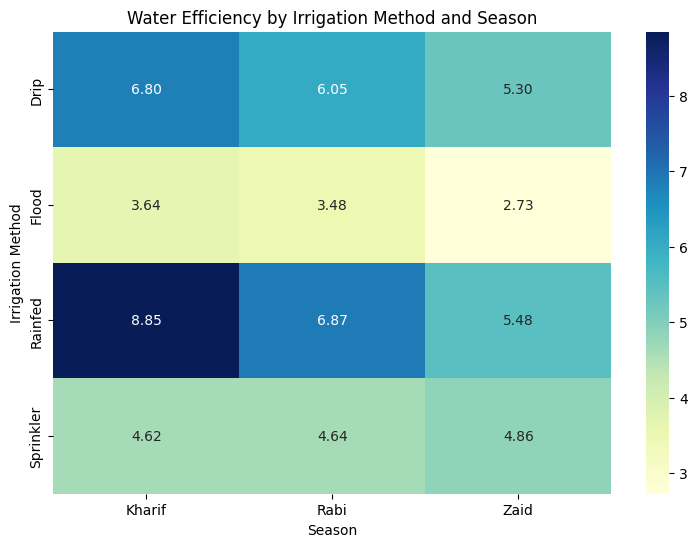

In [86]:
# Heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    irrigation_season_efficiency,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Water Efficiency by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.show()

In [87]:
# Step 8.1: Average revenue by season

revenue_by_season = (
    df_clean.groupby("Season")["Revenue_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Revenue by Season:")
print(revenue_by_season.round(2))

Average Revenue by Season:
Season
Kharif    710719.06
Rabi      601526.05
Zaid      519171.90
Name: Revenue_INR, dtype: float64


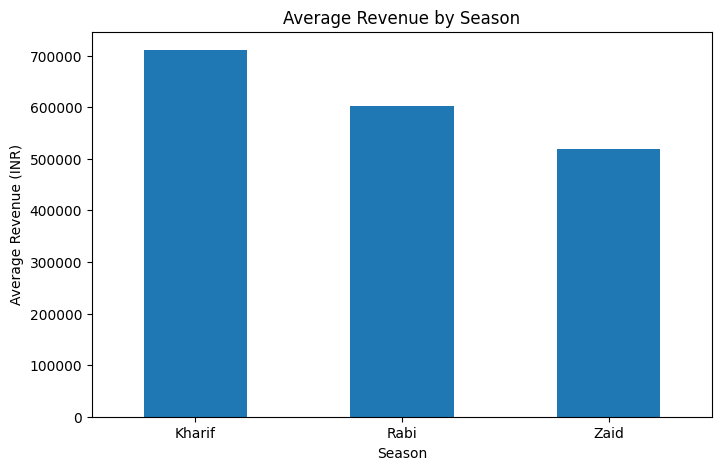

In [88]:
#Visualization
plt.figure(figsize=(8, 5))

revenue_by_season.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=0)

plt.show()

In [89]:
# Average agricultural cost by season

cost_by_season = (
    df_clean.groupby("Season")["Total_Cost_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Cost by Season:")
print(cost_by_season.round(2))

Average Cost by Season:
Season
Zaid      543976.73
Kharif    531804.41
Rabi      513836.58
Name: Total_Cost_INR, dtype: float64


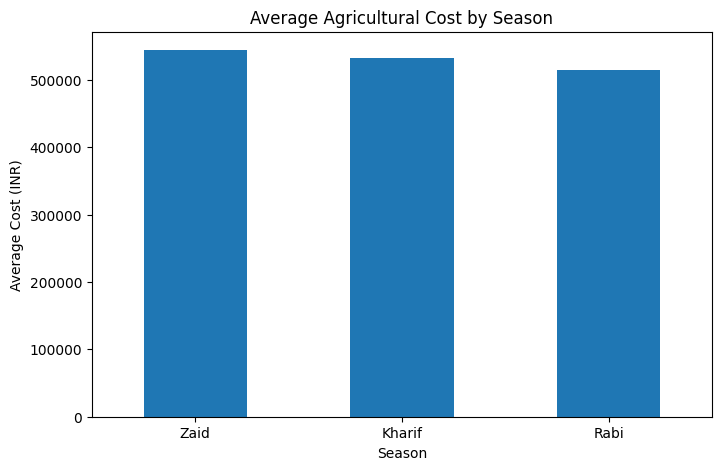

In [90]:
#Visualization
plt.figure(figsize=(8, 5))

cost_by_season.plot(kind="bar")

plt.title("Average Agricultural Cost by Season")
plt.xlabel("Season")
plt.ylabel("Average Cost (INR)")
plt.xticks(rotation=0)

plt.show()

In [91]:
# Average profit by season

profit_by_season = (
    df_clean.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Season:")
print(profit_by_season.round(2))

Average Profit by Season:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64


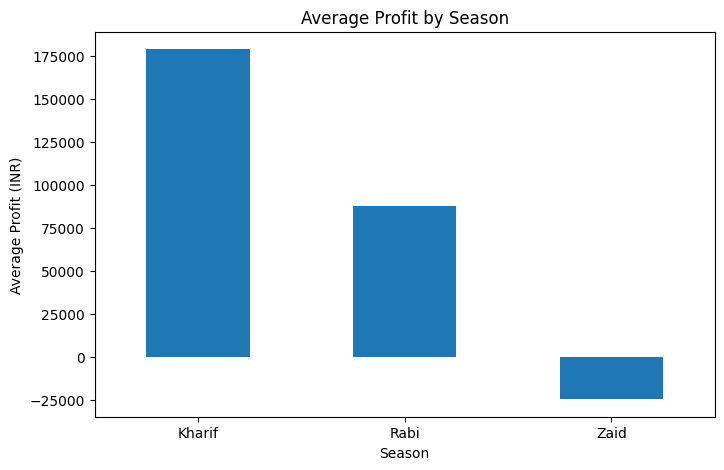

In [92]:
#Visualization
plt.figure(figsize=(8, 5))

profit_by_season.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.show()

In [93]:
# Average profit margin by season

margin_by_season = (
    df_clean.groupby("Season")["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit Margin by Season:")
print(margin_by_season.round(2))

Average Profit Margin by Season:
Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


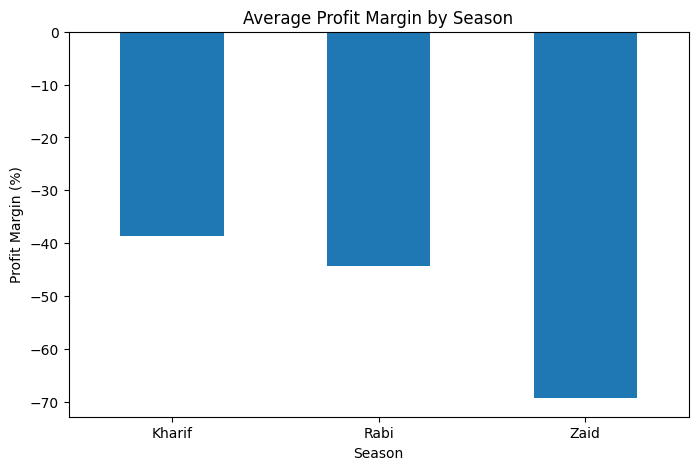

In [94]:
#Visualization
plt.figure(figsize=(8, 5))

margin_by_season.plot(kind="bar")

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)

plt.show()

In [95]:
# Economic performance summary by season

economic_summary = df_clean.groupby("Season").agg(
    Average_Revenue_INR=("Revenue_INR", "mean"),
    Average_Cost_INR=("Total_Cost_INR", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Profit_Margin_pct=("Profit_Margin_pct", "mean")
).round(2)

economic_summary

,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Profit_Margin_pct
Season,,,,
Kharif,710719.06,531804.41,178914.65,-38.64
Rabi,601526.05,513836.58,87689.47,-44.27
Zaid,519171.90,543976.73,-24804.82,-69.35


In [96]:
# Average profit by crop

crop_profit = (
    df_clean.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Crop:")
print(crop_profit.round(2))

Average Profit by Crop:
Crop
Sugarcane    817187.99
Chilli       750878.34
Cotton       124546.92
Groundnut     44858.12
Pulses        -4238.05
Maize        -83978.33
Rice        -102213.50
Wheat       -123398.34
Name: Profit_INR, dtype: float64


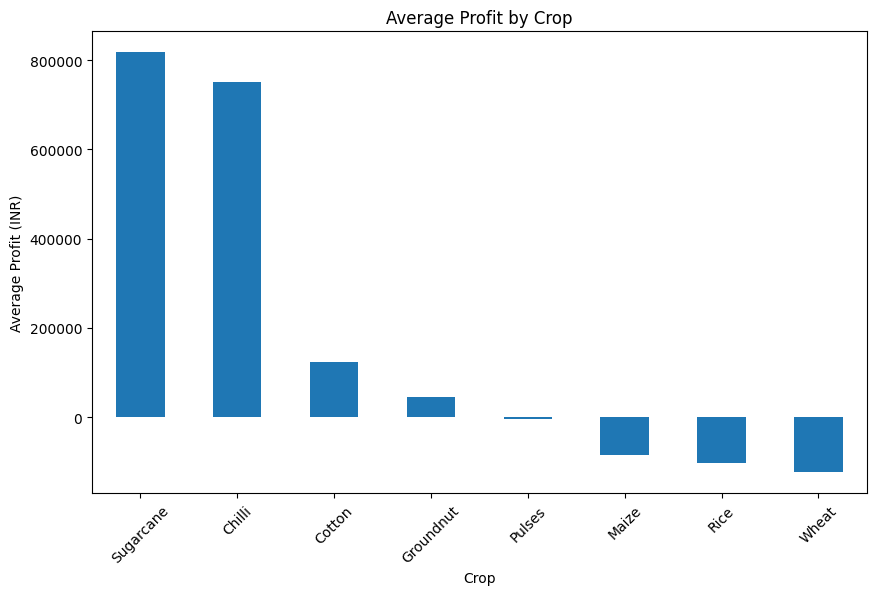

In [97]:
plt.figure(figsize=(10, 6))

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [98]:
# Average profit margin by crop

crop_margin = (
    df_clean.groupby("Crop")["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit Margin by Crop:")
print(crop_margin.round(2))

Average Profit Margin by Crop:
Crop
Chilli       33.78
Sugarcane    27.35
Cotton       -8.23
Groundnut   -28.66
Pulses      -36.48
Maize       -81.54
Wheat       -91.70
Rice        -99.37
Name: Profit_Margin_pct, dtype: float64


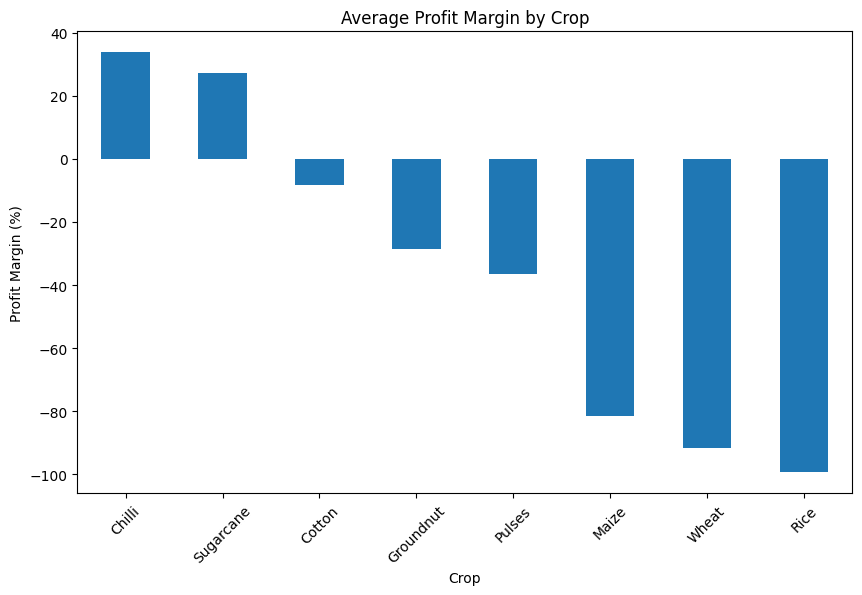

In [99]:
plt.figure(figsize=(10, 6))

crop_margin.plot(kind="bar")

plt.title("Average Profit Margin by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

plt.show()

In [100]:
# Economic performance by state

state_economic = df_clean.groupby("State").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Profit_Margin=("Profit_Margin_pct", "mean")
).round(2)

state_economic

,Average_Revenue,Average_Cost,Average_Profit,Average_Profit_Margin
State,,,,
Andhra Pradesh,606663.66,533210.13,73453.53,-54.69
Gujarat,654692.86,537124.62,117568.24,-54.00
Karnataka,653426.18,534003.85,119422.34,-46.31
Madhya Pradesh,597558.36,510717.60,86840.76,-44.93
Maharashtra,650032.67,514603.81,135428.86,-44.49
Punjab,686225.70,550200.07,136025.64,-45.12
Tamil Nadu,629093.42,511348.67,117744.75,-45.49
Telangana,628784.53,519954.92,108829.62,-29.13


In [101]:
#Average Profit By state
state_profit = (
    df_clean.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by State:")
print(state_profit.round(2))

Average Profit by State:
State
Punjab            136025.64
Maharashtra       135428.86
Karnataka         119422.34
Tamil Nadu        117744.75
Gujarat           117568.24
Telangana         108829.62
Madhya Pradesh     86840.76
Andhra Pradesh     73453.53
Name: Profit_INR, dtype: float64


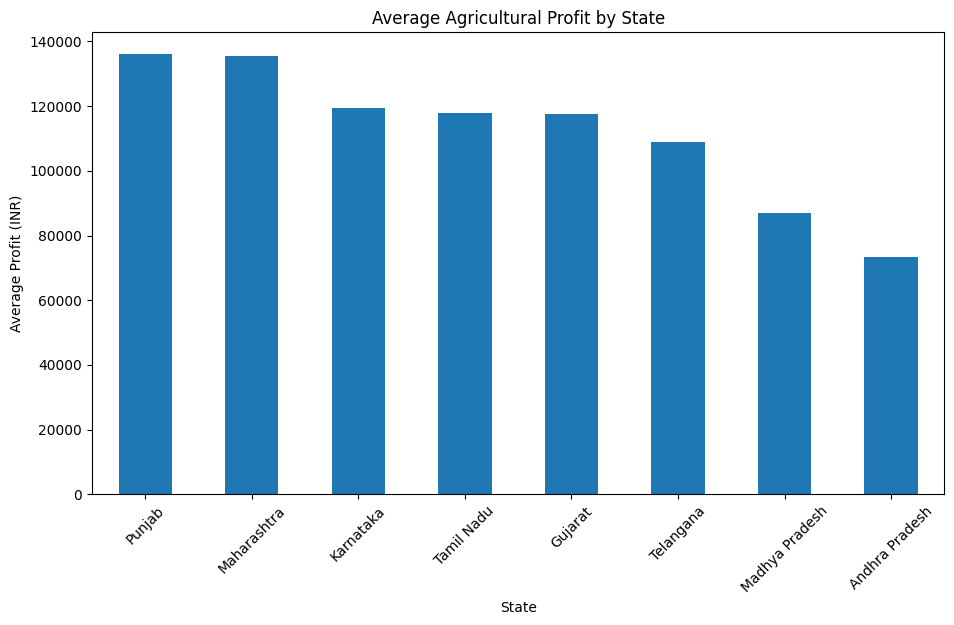

In [102]:
plt.figure(figsize=(11, 6))

state_profit.plot(kind="bar")

plt.title("Average Agricultural Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [103]:
# Average profit by crop and season

season_crop_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

season_crop_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


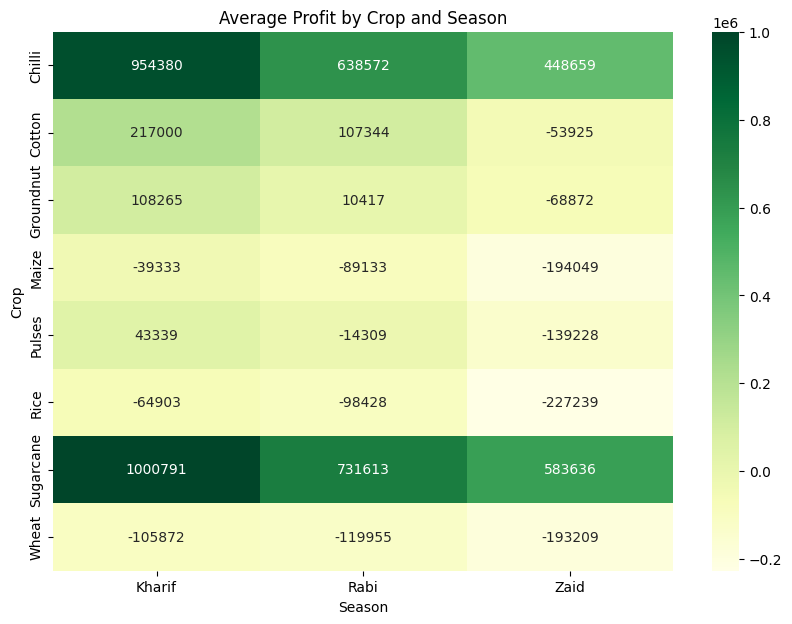

In [104]:
# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    season_crop_profit,
    annot=True,
    fmt=".0f",
    cmap="YlGn"
)

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [105]:
# Average revenue per hectare by season

revenue_per_hectare = (
    df_clean.groupby("Season")[
        "Revenue_per_Hectare_INR"
    ]
    .mean()
    .sort_values(ascending=False)
)

print("Average Revenue per Hectare:")
print(revenue_per_hectare.round(2))

Average Revenue per Hectare:
Season
Kharif    88782.79
Rabi      76656.92
Zaid      64301.42
Name: Revenue_per_Hectare_INR, dtype: float64


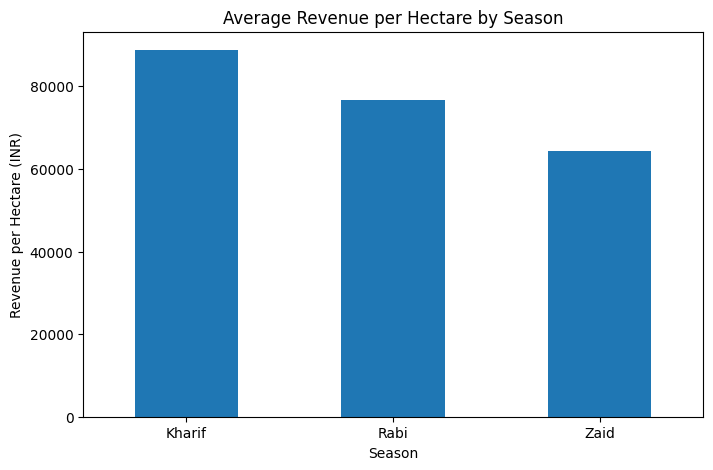

In [106]:
#Visualization
plt.figure(figsize=(8, 5))

revenue_per_hectare.plot(kind="bar")

plt.title("Average Revenue per Hectare by Season")
plt.xlabel("Season")
plt.ylabel("Revenue per Hectare (INR)")
plt.xticks(rotation=0)

plt.show()

In [107]:
#  Average disease/pest risk by season

risk_by_season = (
    df_clean.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Disease/Pest Risk by Season:")
print(risk_by_season.round(2))

Average Disease/Pest Risk by Season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


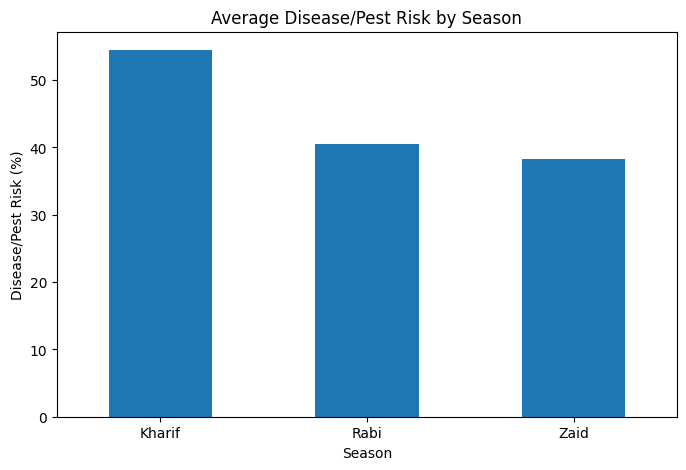

In [108]:
#Visualization
plt.figure(figsize=(8, 5))

risk_by_season.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.xticks(rotation=0)

plt.show()

In [109]:
# Average disease/pest risk by crop

risk_by_crop = (
    df_clean.groupby("Crop")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Disease/Pest Risk by Crop:")
print(risk_by_crop.round(2))

Average Disease/Pest Risk by Crop:
Crop
Wheat        47.85
Pulses       46.57
Rice         46.50
Groundnut    46.29
Chilli       46.06
Cotton       45.97
Maize        45.54
Sugarcane    45.40
Name: Disease_Pest_Risk_pct, dtype: float64


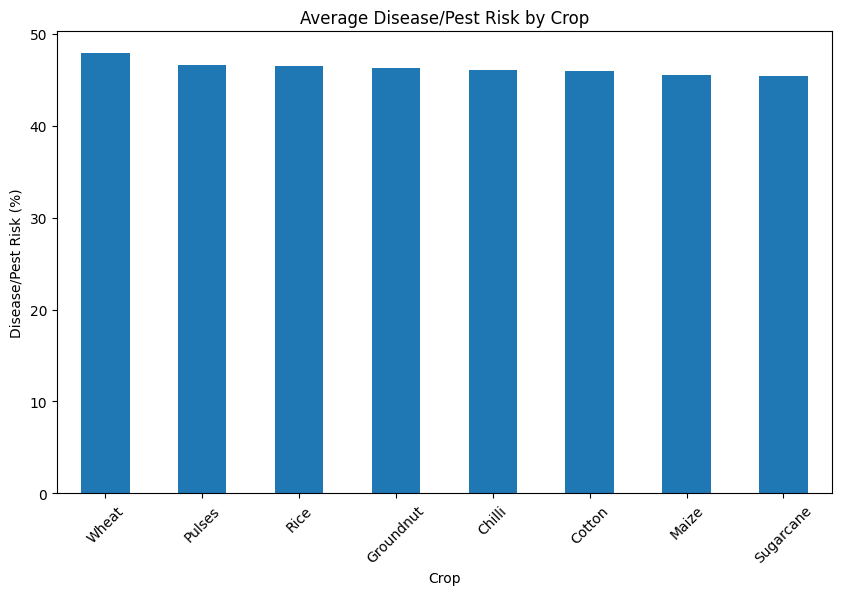

In [110]:
#Visualization
plt.figure(figsize=(10, 6))

risk_by_crop.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Crop")
plt.xlabel("Crop")
plt.ylabel("Disease/Pest Risk (%)")
plt.xticks(rotation=45)

plt.show()

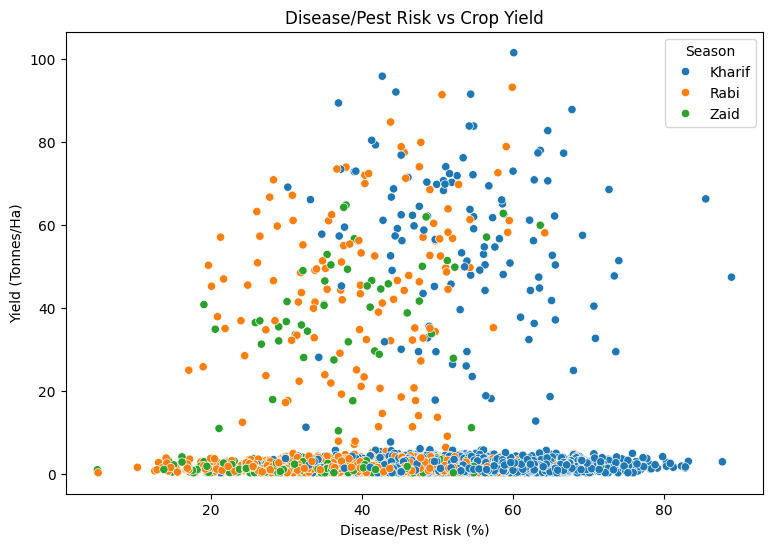

In [111]:
# Disease/Pest Risk vs Yield
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Disease_Pest_Risk_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Disease/Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [112]:
# Correlation between disease/pest risk and yield

risk_yield_corr = df_clean[
    "Disease_Pest_Risk_pct"
].corr(
    df_clean["Yield_Tonnes_Ha"]
)

print(
    "Disease/Pest Risk-Yield Correlation:",
    round(risk_yield_corr, 3)
)

Disease/Pest Risk-Yield Correlation: 0.013


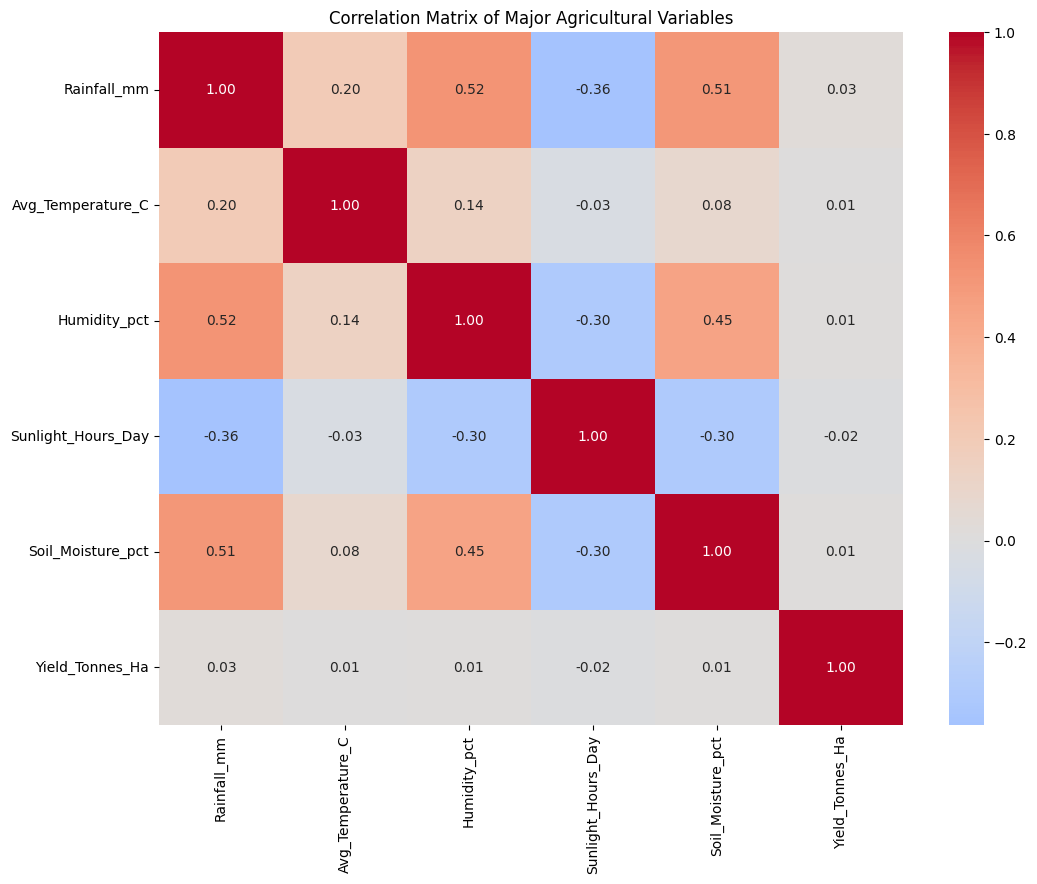

In [113]:
# Heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Major Agricultural Variables")

plt.show()

In [114]:
# Correlation between important agricultural variables

analysis_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Profit_INR"
]

correlation_matrix = df_clean[analysis_columns].corr()

correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.51,0.02,0.00,0.03,0.00,0.06,0.62,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,0.01,0.02,0.01,0.25,0.01
Humidity_pct,0.52,0.14,1.00,0.45,0.02,-0.00,0.01,-0.00,0.03,0.55,0.06
Soil_Moisture_pct,0.51,0.08,0.45,1.00,0.01,-0.02,0.01,0.00,0.03,0.38,0.09
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,1.00,-0.00,-0.00,0.00,0.01,0.02,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.00,1.00,-0.01,0.00,-0.01,-0.47,-0.03
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,-0.00,-0.01,1.00,0.39,0.92,0.01,0.49
Water_Used_m3,0.00,0.02,-0.00,0.00,0.00,0.00,0.39,1.00,0.22,0.01,0.19
Water_Efficiency_t_per_1000m3,0.06,0.01,0.03,0.03,0.01,-0.01,0.92,0.22,1.00,0.03,0.49
Disease_Pest_Risk_pct,0.62,0.25,0.55,0.38,0.02,-0.47,0.01,0.01,0.03,1.00,0.07


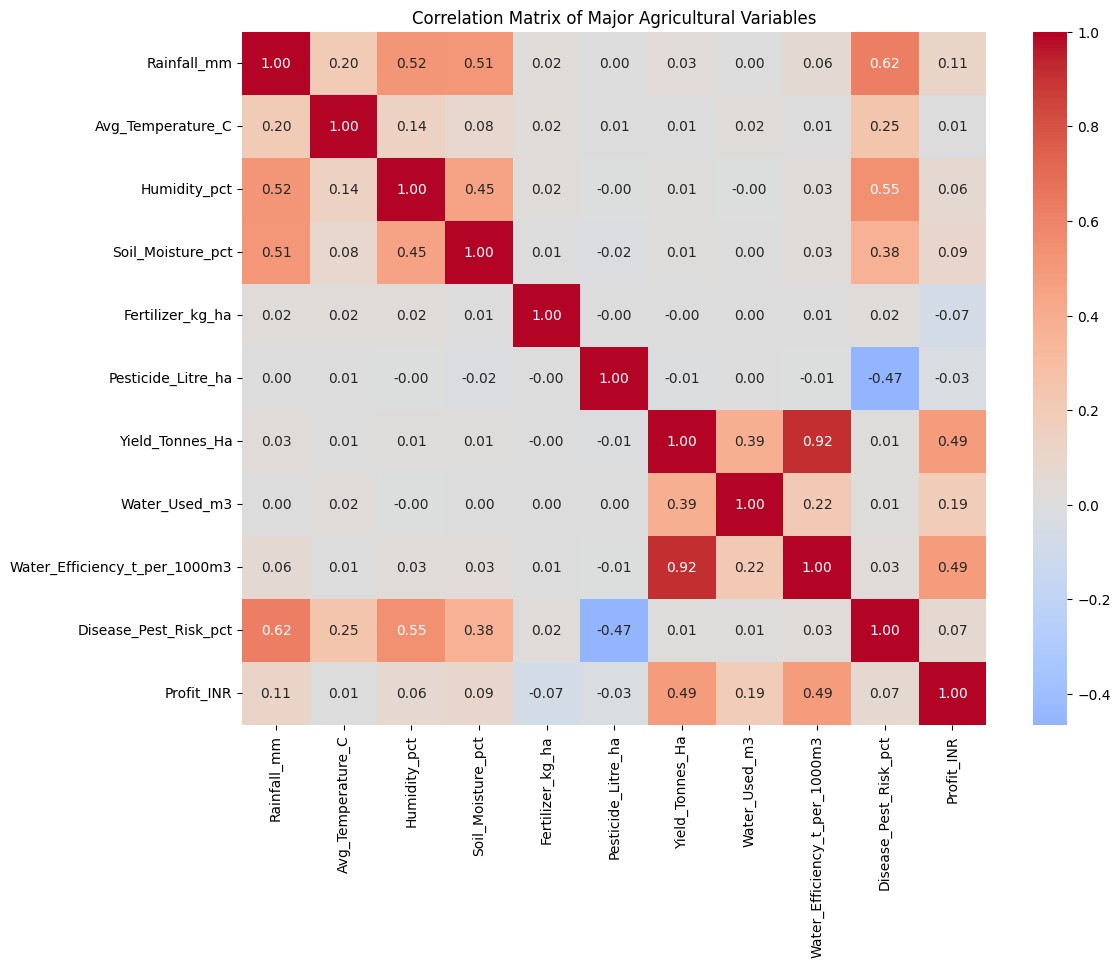

In [122]:
#Visualization
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Major Agricultural Variables")

plt.show()

In [123]:
# Step 9.6: One-way ANOVA for seasonal yield

from scipy.stats import f_oneway

kharif_yield = df_clean[
    df_clean["Season"] == "Kharif"
]["Yield_Tonnes_Ha"]

rabi_yield = df_clean[
    df_clean["Season"] == "Rabi"
]["Yield_Tonnes_Ha"]

zaid_yield = df_clean[
    df_clean["Season"] == "Zaid"
]["Yield_Tonnes_Ha"]

anova_result = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_result.statistic, 3))
print("ANOVA p-value:", anova_result.pvalue)

ANOVA F-statistic: nan
ANOVA p-value: nan


In [124]:
# One-way ANOVA for seasonal profit

kharif_profit = df_clean[
    df_clean["Season"] == "Kharif"
]["Profit_INR"]

rabi_profit = df_clean[
    df_clean["Season"] == "Rabi"
]["Profit_INR"]

zaid_profit = df_clean[
    df_clean["Season"] == "Zaid"
]["Profit_INR"]

profit_anova = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Profit ANOVA F-statistic:",
      round(profit_anova.statistic, 3))

print("Profit ANOVA p-value:",
      profit_anova.pvalue)

Profit ANOVA F-statistic: 34.292
Profit ANOVA p-value: 1.7124156677360182e-15


In [125]:
# Statistical test summary

statistical_results = pd.DataFrame({
    "Analysis": [
        "Yield across Seasons",
        "Profit across Seasons"
    ],
    "F_Statistic": [
        anova_result.statistic,
        profit_anova.statistic
    ],
    "P_Value": [
        anova_result.pvalue,
        profit_anova.pvalue
    ]
})

statistical_results["Significant_at_5_percent"] = (
    statistical_results["P_Value"] < 0.05
)

statistical_results.round(4)

,Analysis,F_Statistic,P_Value,Significant_at_5_percent
0,Yield across Seasons,NaN,NaN,False
1,Profit across Seasons,34.2918,0.0,True


In [126]:
# Number of agricultural records by state

state_counts = df_clean["State"].value_counts()

print("Number of records by state:")
print(state_counts)

Number of records by state:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


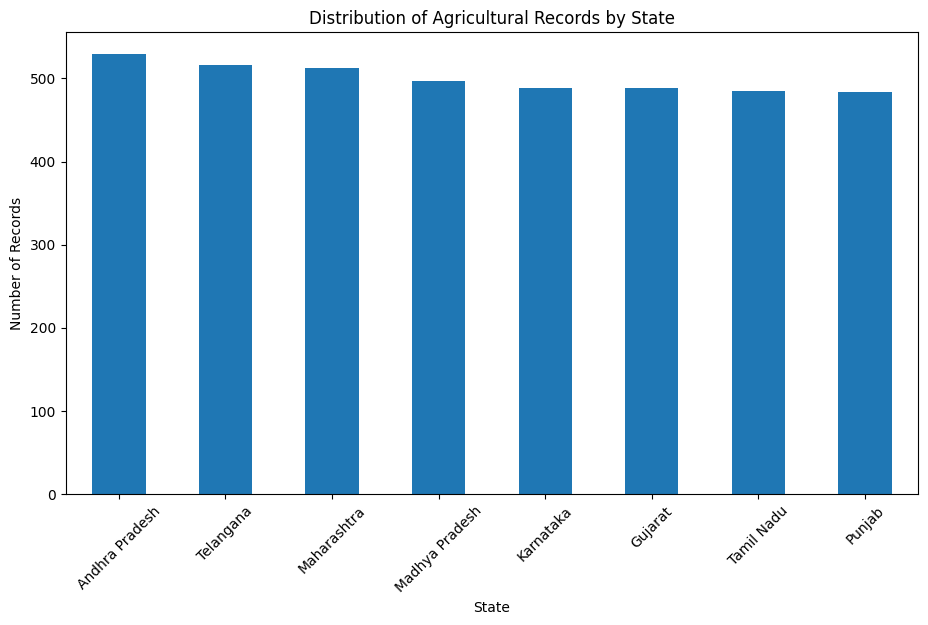

In [127]:
#Visualization
plt.figure(figsize=(11, 6))

state_counts.plot(kind="bar")

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

In [128]:
# Average yield by state

state_yield = (
    df_clean.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by State:")
print(state_yield.round(2))

Average Yield by State:
State
Punjab            6.12
Karnataka         5.73
Gujarat           5.70
Telangana         5.08
Maharashtra       5.03
Madhya Pradesh    5.03
Tamil Nadu        4.90
Andhra Pradesh    4.65
Name: Yield_Tonnes_Ha, dtype: float64


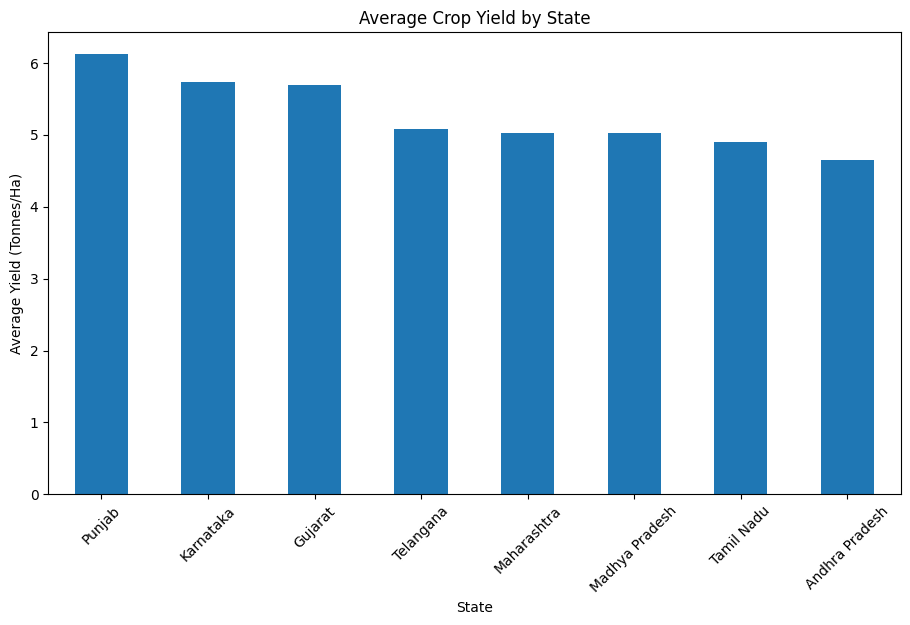

In [129]:
#Visualization
plt.figure(figsize=(11, 6))

state_yield.plot(kind="bar")

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.show()

In [130]:
# Average profit by state

state_profit = (
    df_clean.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by State:")
print(state_profit.round(2))

Average Profit by State:
State
Punjab            136025.64
Maharashtra       135428.86
Karnataka         119422.34
Tamil Nadu        117744.75
Gujarat           117568.24
Telangana         108829.62
Madhya Pradesh     86840.76
Andhra Pradesh     73453.53
Name: Profit_INR, dtype: float64


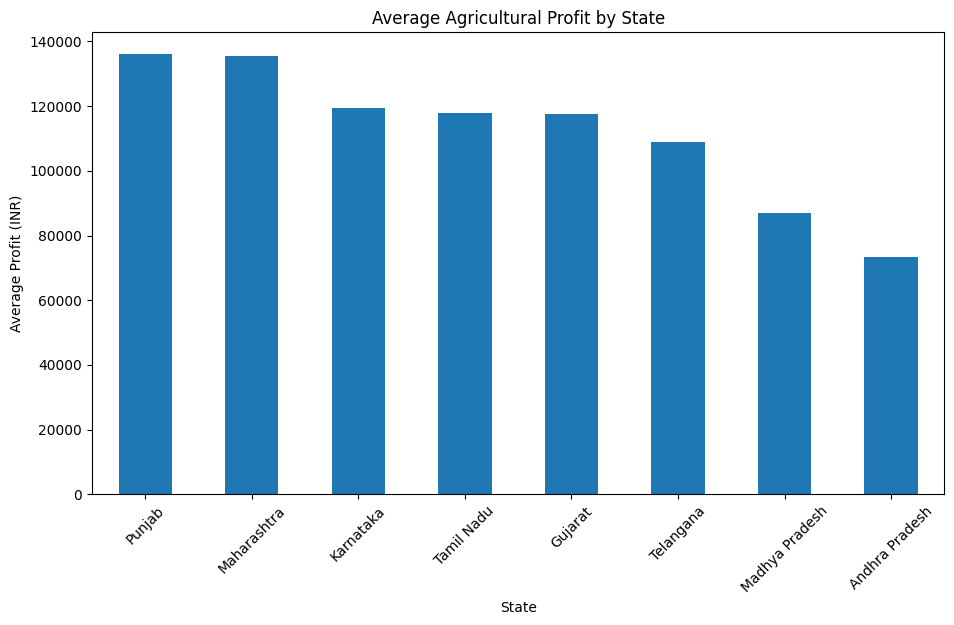

In [131]:
#Visualization
plt.figure(figsize=(11, 6))

state_profit.plot(kind="bar")

plt.title("Average Agricultural Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)

plt.show()

In [132]:
# Average water efficiency by state

state_water_efficiency = (
    df_clean.groupby("State")[
        "Water_Efficiency_t_per_1000m3"
    ]
    .mean()
    .sort_values(ascending=False)
)

print("Average Water Efficiency by State:")
print(state_water_efficiency.round(2))

Average Water Efficiency by State:
State
Punjab            5.62
Gujarat           5.58
Karnataka         5.56
Telangana         5.46
Tamil Nadu        5.31
Maharashtra       5.28
Madhya Pradesh    5.27
Andhra Pradesh    5.03
Name: Water_Efficiency_t_per_1000m3, dtype: float64


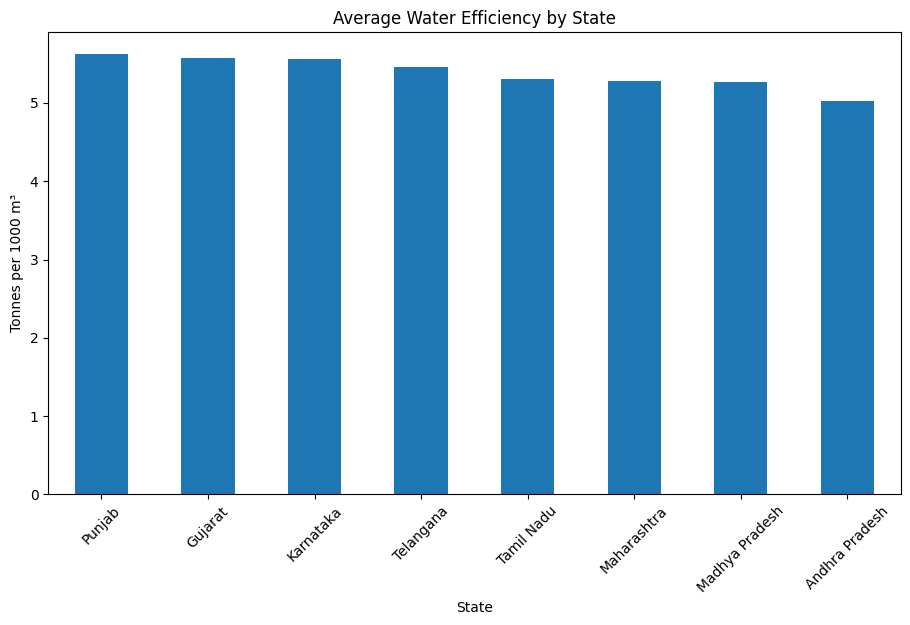

In [133]:
#Visualization
plt.figure(figsize=(11, 6))

state_water_efficiency.plot(kind="bar")

plt.title("Average Water Efficiency by State")
plt.xlabel("State")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=45)

plt.show()

In [134]:
# Average yield by state and season

state_season_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


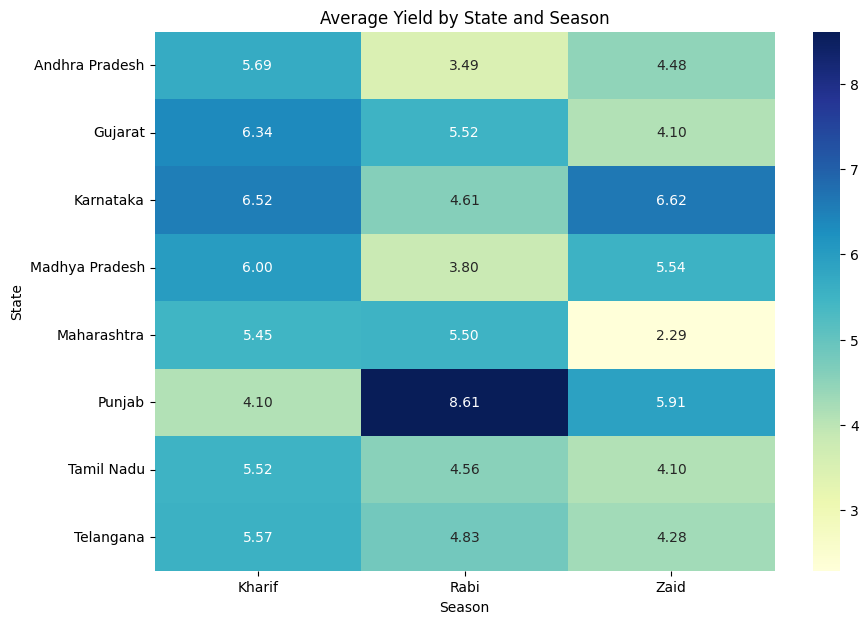

In [135]:
#State x Season Yield Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.show()

In [136]:
# Average profit by state and season

state_season_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="State",
    columns="Season",
    aggfunc="mean"
).round(2)

state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


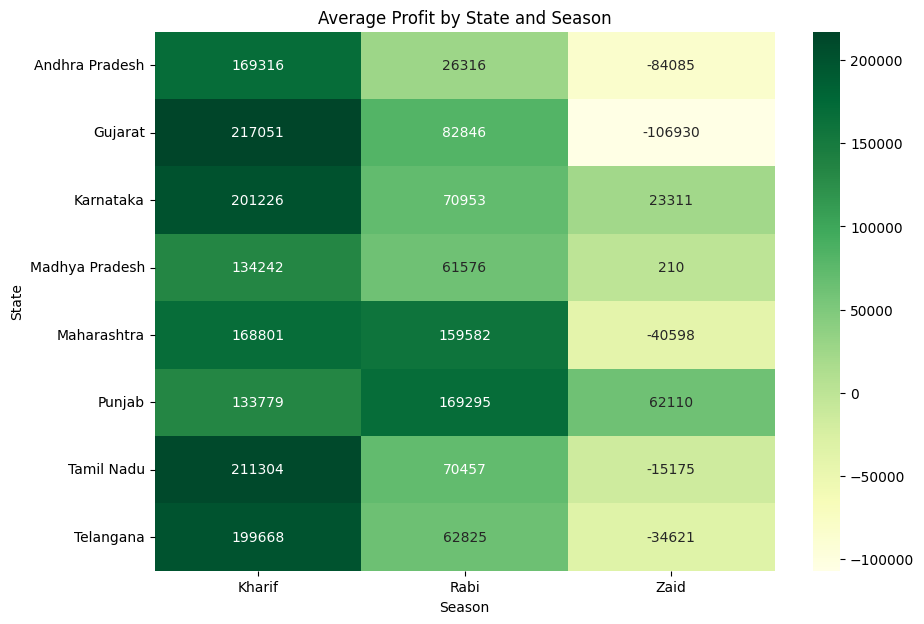

In [137]:
#Visualization
plt.figure(figsize=(10, 7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt=".0f",
    cmap="YlGn"
)

plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.show()

In [138]:
# State-wise agricultural performance summary

state_summary = df_clean.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Average_Disease_Risk=(
        "Disease_Pest_Risk_pct", "mean"
    )
).round(2)

state_summary

,Average_Yield,Average_Production,Average_Revenue,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
State,,,,,,
Andhra Pradesh,4.65,36.91,606663.66,73453.53,5.03,46.72
Gujarat,5.70,48.33,654692.86,117568.24,5.58,45.95
Karnataka,5.73,47.73,653426.18,119422.34,5.56,46.06
Madhya Pradesh,5.03,37.56,597558.36,86840.76,5.27,47.08
Maharashtra,5.03,43.98,650032.67,135428.86,5.28,46.44
Punjab,6.12,52.23,686225.70,136025.64,5.62,46.00
Tamil Nadu,4.90,40.84,629093.42,117744.75,5.31,46.28
Telangana,5.08,39.25,628784.53,108829.62,5.46,46.36


In [139]:
# Top 3 states by average yield

top_3_yield_states = state_yield.head(3)

print("Top 3 States by Average Yield:")
print(top_3_yield_states.round(2))

Top 3 States by Average Yield:
State
Punjab       6.12
Karnataka    5.73
Gujarat      5.70
Name: Yield_Tonnes_Ha, dtype: float64


In [140]:
# Top 3 states by water efficiency

top_3_water_states = state_water_efficiency.head(3)

print("Top 3 States by Water Efficiency:")
print(top_3_water_states.round(2))

Top 3 States by Water Efficiency:
State
Punjab       5.62
Gujarat      5.58
Karnataka    5.56
Name: Water_Efficiency_t_per_1000m3, dtype: float64


In [141]:
# Select important numerical columns for outlier analysis

key_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Disease_Pest_Risk_pct"
]

print("Columns selected for outlier analysis:")
for col in key_columns:
    print("-", col)

Columns selected for outlier analysis:
- Yield_Tonnes_Ha
- Production_Tonnes
- Profit_INR
- Rainfall_mm
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Disease_Pest_Risk_pct


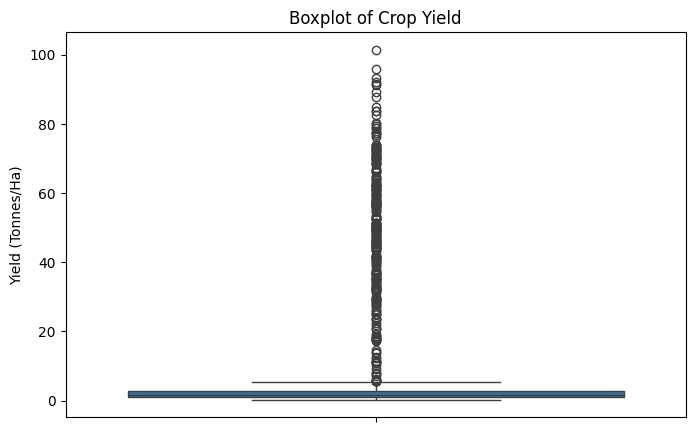

In [142]:
# Boxplot for Yield

plt.figure(figsize=(8, 5))
sns.boxplot(y=df_clean["Yield_Tonnes_Ha"])

plt.title("Boxplot of Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

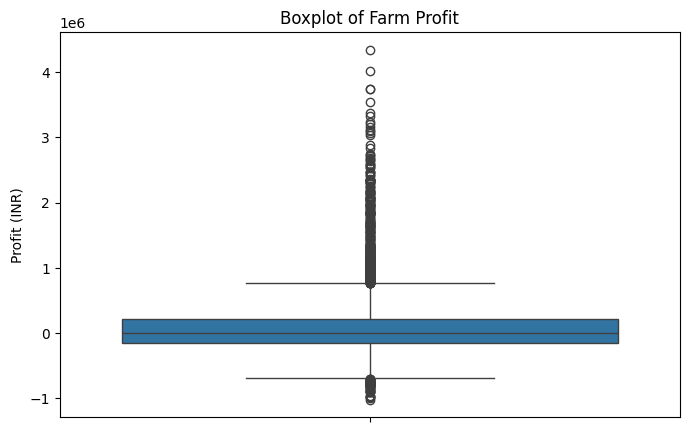

In [143]:
# Boxplot for Profit

plt.figure(figsize=(8, 5))
sns.boxplot(y=df_clean["Profit_INR"])

plt.title("Boxplot of Farm Profit")
plt.ylabel("Profit (INR)")
plt.show()

In [144]:
# Detect statistical outliers using IQR

outlier_results = []

for col in key_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()

    outlier_results.append([
        col,
        Q1,
        Q3,
        lower_bound,
        upper_bound,
        outlier_count
    ])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count"
    ]
)

outlier_table = outlier_table.sort_values(
    "Outlier_Count",
    ascending=False
)

outlier_table

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
2,Profit_INR,-148731.750,216187.75000,-696111.000000,7.635670e+05,404
1,Production_Tonnes,5.020,24.35500,-23.982500,5.335750e+01,333
5,Water_Efficiency_t_per_1000m3,1.661,5.15025,-3.572875,1.038412e+01,322
0,Yield_Tonnes_Ha,1.050,2.84000,-1.635000,5.525000e+00,302
4,Water_Used_m3,2268.750,7829.75000,-6072.750000,1.617125e+04,276
8,Revenue_INR,207517.250,836874.75000,-736519.000000,1.780911e+06,240
9,Disease_Pest_Risk_pct,37.300,54.90000,10.900000,8.130000e+01,10
3,Rainfall_mm,370.200,834.95000,-326.925000,1.532075e+03,0
7,Total_Cost_INR,274577.500,761996.50000,-456551.000000,1.493125e+06,0
6,Market_Price_INR_Tonne,21429.250,68279.00000,-48845.375000,1.385536e+05,0


In [145]:
# Step 11.5: Top 10 highest-yield farms

top_yield_farms = df_clean.nlargest(
    10,
    "Yield_Tonnes_Ha"
)[[
    "Farm_ID",
    "State",
    "District",
    "Season",
    "Crop",
    "Farm_Area_Hectares",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Irrigation_Method"
]]

top_yield_farms

,Farm_ID,State,District,Season,Crop,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Irrigation_Method
1715,SF11716,Gujarat,Indore,Kharif,Sugarcane,6.32,101.44,641.10,Drip
3423,SF13424,Andhra Pradesh,Indore,Kharif,Sugarcane,14.87,95.79,1424.40,Drip
3525,SF13526,Andhra Pradesh,Erode,Rabi,Sugarcane,6.96,93.13,648.18,Drip
1464,SF11465,Gujarat,Nashik,Kharif,Sugarcane,7.65,91.98,703.65,Drip
3523,SF13524,Karnataka,Nashik,Kharif,Sugarcane,0.82,91.46,75.00,Flood
2782,SF12783,Gujarat,Nalgonda,Rabi,Sugarcane,5.72,91.32,522.35,Flood
644,SF10645,Andhra Pradesh,Ludhiana,Kharif,Sugarcane,7.48,89.34,668.26,Drip
2847,SF12848,Telangana,Warangal,Kharif,Sugarcane,7.66,87.76,672.24,Drip
357,SF10358,Punjab,Warangal,Rabi,Sugarcane,14.74,84.75,1249.21,Sprinkler
1178,SF11179,Karnataka,Nalgonda,Kharif,Sugarcane,6.38,83.79,534.58,Drip


In [146]:
# Top 10 farms with the lowest profit

lowest_profit_farms = df_clean.nsmallest(
    10,
    "Profit_INR"
)[[
    "Farm_ID",
    "State",
    "District",
    "Season",
    "Crop",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR",
    "Farm_Area_Hectares"
]]

lowest_profit_farms

,Farm_ID,State,District,Season,Crop,Revenue_INR,Total_Cost_INR,Profit_INR,Farm_Area_Hectares
780,SF10781,Andhra Pradesh,Ludhiana,Rabi,Groundnut,280139,1299362,-1019223,14.64
2210,SF12211,Andhra Pradesh,Raichur,Rabi,Wheat,102497,1097692,-995195,14.27
3625,SF13626,Punjab,Krishna,Rabi,Maize,226503,1207553,-981050,13.47
2182,SF12183,Andhra Pradesh,Krishna,Kharif,Rice,320865,1297725,-976860,14.72
104,SF10105,Gujarat,Krishna,Zaid,Wheat,98792,1063989,-965197,12.30
3394,SF13395,Gujarat,Erode,Kharif,Wheat,99644,1063040,-963396,13.41
2730,SF12731,Madhya Pradesh,Ludhiana,Rabi,Rice,89197,995279,-906082,11.99
1311,SF11312,Punjab,Rajkot,Zaid,Rice,163084,1065824,-902740,13.55
585,SF10586,Telangana,Warangal,Zaid,Cotton,198300,1094030,-895730,13.96
3090,SF13091,Karnataka,Ludhiana,Kharif,Maize,109026,999667,-890641,14.39


In [147]:
# Analyze farms with negative profit

negative_profit_count = (
    df_clean["Profit_INR"] < 0
).sum()

negative_profit_percentage = (
    negative_profit_count / len(df_clean)
) * 100

print("Number of farms with negative profit:", negative_profit_count)
print("Percentage of farms with negative profit:",
      round(negative_profit_percentage, 2), "%")

Number of farms with negative profit: 1966
Percentage of farms with negative profit: 49.15 %


In [148]:
# Compare yield distribution across seasons

season_yield_distribution = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

season_yield_distribution

,count,mean,median,min,max
Season,,,,,
Kharif,1772,5.64,1.95,0.3,101.44
Rabi,1607,5.08,1.66,0.3,93.13
Zaid,589,4.67,1.45,0.3,64.76


In [149]:
# Check production consistency

calculated_production = (
    df_clean["Yield_Tonnes_Ha"] *
    df_clean["Farm_Area_Hectares"]
)

production_difference = (
    df_clean["Production_Tonnes"] -
    calculated_production
)

print("Production consistency check:")
print(production_difference.abs().describe())

Production consistency check:
count    3968.000000
mean        0.002487
std         0.001481
min         0.000000
25%         0.001200
50%         0.002500
75%         0.003800
max         0.005000
dtype: float64


In [150]:
# Check profit consistency

calculated_profit = (
    df_clean["Revenue_INR"] -
    df_clean["Total_Cost_INR"]
)

profit_difference = (
    df_clean["Profit_INR"] -
    calculated_profit
)

print("Profit consistency check:")
print(profit_difference.abs().describe())

Profit consistency check:
count    4000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64


In [151]:
#  Compare unusual seasonal patterns

season_extremes = (
    df_clean.groupby("Season")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Median_Yield=("Yield_Tonnes_Ha", "median"),
        Maximum_Yield=("Yield_Tonnes_Ha", "max"),
        Minimum_Yield=("Yield_Tonnes_Ha", "min"),
        Average_Profit=("Profit_INR", "mean"),
        Minimum_Profit=("Profit_INR", "min"),
        Maximum_Profit=("Profit_INR", "max")
    )
    .round(2)
)

season_extremes

,Average_Yield,Median_Yield,Maximum_Yield,Minimum_Yield,Average_Profit,Minimum_Profit,Maximum_Profit
Season,,,,,,,
Kharif,5.64,1.95,101.44,0.3,178914.65,-976860,4345421
Rabi,5.08,1.66,93.13,0.3,87689.47,-1019223,3378879
Zaid,4.67,1.45,64.76,0.3,-24804.82,-965197,2349990


In [152]:
# Final outlier summary

print("OUTLIER & UNUSUAL PATTERN ANALYSIS")
print("-----------------------------------")

print("\n1. Total records:", len(df_clean))

print("\n2. Negative-profit farms:",
      (df_clean["Profit_INR"] < 0).sum())

print("\n3. Highest yield:",
      round(df_clean["Yield_Tonnes_Ha"].max(), 2),
      "Tonnes/Ha")

print("\n4. Lowest yield:",
      round(df_clean["Yield_Tonnes_Ha"].min(), 2),
      "Tonnes/Ha")

print("\n5. Highest profit:",
      round(df_clean["Profit_INR"].max(), 2),
      "INR")

print("\n6. Lowest profit:",
      round(df_clean["Profit_INR"].min(), 2),
      "INR")

OUTLIER & UNUSUAL PATTERN ANALYSIS
-----------------------------------

1. Total records: 4000

2. Negative-profit farms: 1966

3. Highest yield: 101.44 Tonnes/Ha

4. Lowest yield: 0.3 Tonnes/Ha

5. Highest profit: 4345421 INR

6. Lowest profit: -1019223 INR


In [153]:
# Step 12.1: Identify overall best-performing categories

best_season_yield = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

best_season_profit = (
    df_clean.groupby("Season")["Profit_INR"]
    .mean()
    .idxmax()
)

best_crop_yield = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

best_crop_profit = (
    df_clean.groupby("Crop")["Profit_INR"]
    .mean()
    .idxmax()
)

best_state_yield = (
    df_clean.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

best_state_profit = (
    df_clean.groupby("State")["Profit_INR"]
    .mean()
    .idxmax()
)

best_irrigation_efficiency = (
    df_clean.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .idxmax()
)

print("Best season by average yield:", best_season_yield)
print("Best season by average profit:", best_season_profit)
print("Best crop by average yield:", best_crop_yield)
print("Best crop by average profit:", best_crop_profit)
print("Best state by average yield:", best_state_yield)
print("Best state by average profit:", best_state_profit)
print("Best irrigation method by water efficiency:",
      best_irrigation_efficiency)

Best season by average yield: Kharif
Best season by average profit: Kharif
Best crop by average yield: Sugarcane
Best crop by average profit: Sugarcane
Best state by average yield: Punjab
Best state by average profit: Punjab
Best irrigation method by water efficiency: Rainfed


In [154]:
# Calculate important overall statistics

overall_avg_yield = df_clean["Yield_Tonnes_Ha"].mean()
overall_avg_profit = df_clean["Profit_INR"].mean()
overall_avg_revenue = df_clean["Revenue_INR"].mean()
overall_avg_water_efficiency = (
    df_clean["Water_Efficiency_t_per_1000m3"].mean()
)

rainfall_yield_corr = (
    df_clean["Rainfall_mm"]
    .corr(df_clean["Yield_Tonnes_Ha"])
)

soil_yield_corr = (
    df_clean["Soil_Moisture_pct"]
    .corr(df_clean["Yield_Tonnes_Ha"])
)

water_yield_corr = (
    df_clean["Water_Used_m3"]
    .corr(df_clean["Yield_Tonnes_Ha"])
)

risk_yield_corr = (
    df_clean["Disease_Pest_Risk_pct"]
    .corr(df_clean["Yield_Tonnes_Ha"])
)

print("Overall average yield:",
      round(overall_avg_yield, 2), "Tonnes/Ha")

print("Overall average profit:",
      round(overall_avg_profit, 2), "INR")

print("Overall average revenue:",
      round(overall_avg_revenue, 2), "INR")

print("Average water efficiency:",
      round(overall_avg_water_efficiency, 2))

print("Rainfall-Yield correlation:",
      round(rainfall_yield_corr, 3))

print("Soil Moisture-Yield correlation:",
      round(soil_yield_corr, 3))

print("Water Usage-Yield correlation:",
      round(water_yield_corr, 3))

print("Disease/Pest Risk-Yield correlation:",
      round(risk_yield_corr, 3))

Overall average yield: 5.27 Tonnes/Ha
Overall average profit: 111556.46 INR
Overall average revenue: 637860.05 INR
Average water efficiency: 5.39
Rainfall-Yield correlation: 0.031
Soil Moisture-Yield correlation: 0.01
Water Usage-Yield correlation: 0.389
Disease/Pest Risk-Yield correlation: 0.013


In [155]:
# Final performance summary

final_summary = pd.DataFrame({
    "Metric": [
        "Average Yield",
        "Average Profit",
        "Average Revenue",
        "Average Water Efficiency",
        "Best Season by Yield",
        "Best Season by Profit",
        "Best Crop by Yield",
        "Best Crop by Profit",
        "Best State by Yield",
        "Best State by Profit",
        "Best Irrigation Method by Water Efficiency"
    ],

    "Result": [
        round(overall_avg_yield, 2),
        round(overall_avg_profit, 2),
        round(overall_avg_revenue, 2),
        round(overall_avg_water_efficiency, 2),
        best_season_yield,
        best_season_profit,
        best_crop_yield,
        best_crop_profit,
        best_state_yield,
        best_state_profit,
        best_irrigation_efficiency
    ]
})

final_summary

,Metric,Result
0,Average Yield,5.27
1,Average Profit,111556.46
2,Average Revenue,637860.05
3,Average Water Efficiency,5.39
4,Best Season by Yield,Kharif
5,Best Season by Profit,Kharif
6,Best Crop by Yield,Sugarcane
7,Best Crop by Profit,Sugarcane
8,Best State by Yield,Punjab
9,Best State by Profit,Punjab


In [156]:
#Identify the most productive crop-season combination

crop_season_performance = (
    df_clean.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Revenue=("Revenue_INR", "mean")
    )
    .reset_index()
)

best_crop_season = crop_season_performance.loc[
    crop_season_performance["Average_Yield"].idxmax()
]

print("Best crop-season combination by average yield:")
print(best_crop_season)

Best crop-season combination by average yield:
Season                  Kharif
Crop                 Sugarcane
Average_Yield         53.45912
Average_Profit     1000790.808
Average_Revenue     1561828.16
Name: 6, dtype: object


In [158]:
# Best crop-season combination by profit

best_profit_combination = crop_season_performance.loc[
    crop_season_performance["Average_Profit"].idxmax()
]

print("Best crop-season combination by average profit:")
print(best_profit_combination)

Best crop-season combination by average profit:
Season                  Kharif
Crop                 Sugarcane
Average_Yield         53.45912
Average_Profit     1000790.808
Average_Revenue     1561828.16
Name: 6, dtype: object


In [159]:
# Create a compact insight table

insights = pd.DataFrame({
    "Area": [
        "Seasonal Performance",
        "Environmental Factors",
        "Crop Performance",
        "Resource Usage",
        "Economic Performance",
        "Regional Performance",
        "Disease/Pest Risk"
    ],

    "Key Metric": [
        f"Best yield season: {best_season_yield}",
        f"Rainfall-Yield correlation: {rainfall_yield_corr:.3f}",
        f"Best yield crop: {best_crop_yield}",
        f"Best water efficiency: {best_irrigation_efficiency}",
        f"Best profit season: {best_season_profit}",
        f"Best yield state: {best_state_yield}",
        f"Risk-Yield correlation: {risk_yield_corr:.3f}"
    ]
})

insights

,Area,Key Metric
0,Seasonal Performance,Best yield season: Kharif
1,Environmental Factors,Rainfall-Yield correlation: 0.031
2,Crop Performance,Best yield crop: Sugarcane
3,Resource Usage,Best water efficiency: Rainfed
4,Economic Performance,Best profit season: Kharif
5,Regional Performance,Best yield state: Punjab
6,Disease/Pest Risk,Risk-Yield correlation: 0.013


In [160]:
# Import libraries for final dashboard

import matplotlib.pyplot as plt
import seaborn as sns

print("Dashboard libraries ready!")

Dashboard libraries ready!


In [161]:
# Calculate important KPIs

total_farms = df_clean["Farm_ID"].nunique()
total_states = df_clean["State"].nunique()
total_crops = df_clean["Crop"].nunique()

average_yield = df_clean["Yield_Tonnes_Ha"].mean()
average_profit = df_clean["Profit_INR"].mean()

best_season = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

best_crop = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

best_irrigation = (
    df_clean.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .idxmax()
)

print("FINAL DASHBOARD KPIs")
print("--------------------")
print("Total Farms:", total_farms)
print("Total States:", total_states)
print("Total Crops:", total_crops)
print("Average Yield:", round(average_yield, 2), "Tonnes/Ha")
print("Average Profit:", round(average_profit, 2), "INR")
print("Best Season:", best_season)
print("Best Crop:", best_crop)
print("Most Water-Efficient Irrigation:", best_irrigation)

FINAL DASHBOARD KPIs
--------------------
Total Farms: 4000
Total States: 8
Total Crops: 8
Average Yield: 5.27 Tonnes/Ha
Average Profit: 111556.46 INR
Best Season: Kharif
Best Crop: Sugarcane
Most Water-Efficient Irrigation: Rainfed


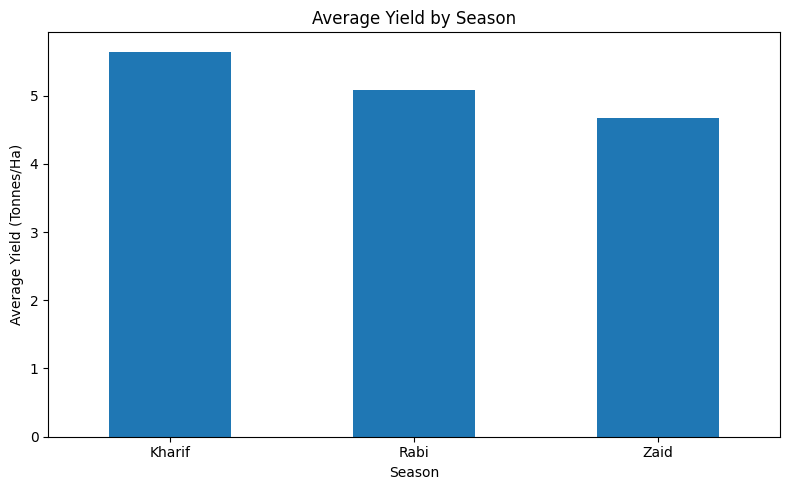

In [162]:
#  Seasonal average yield

season_yield = (
    df_clean.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

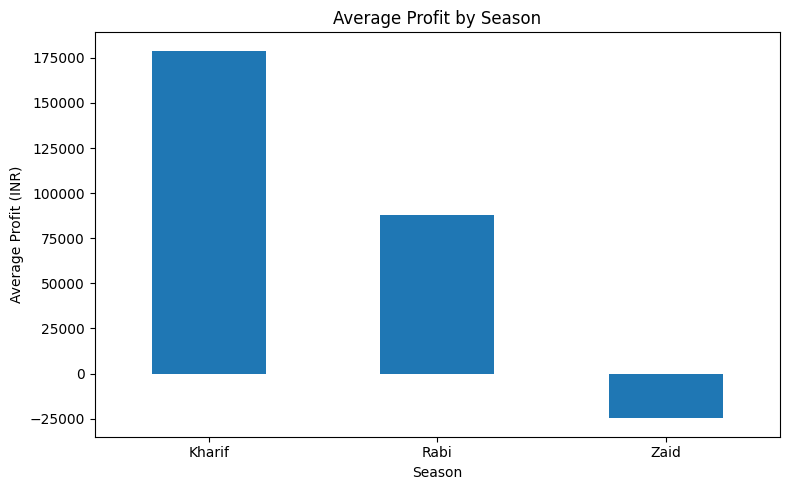

In [163]:
# Seasonal average profit

season_profit = (
    df_clean.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

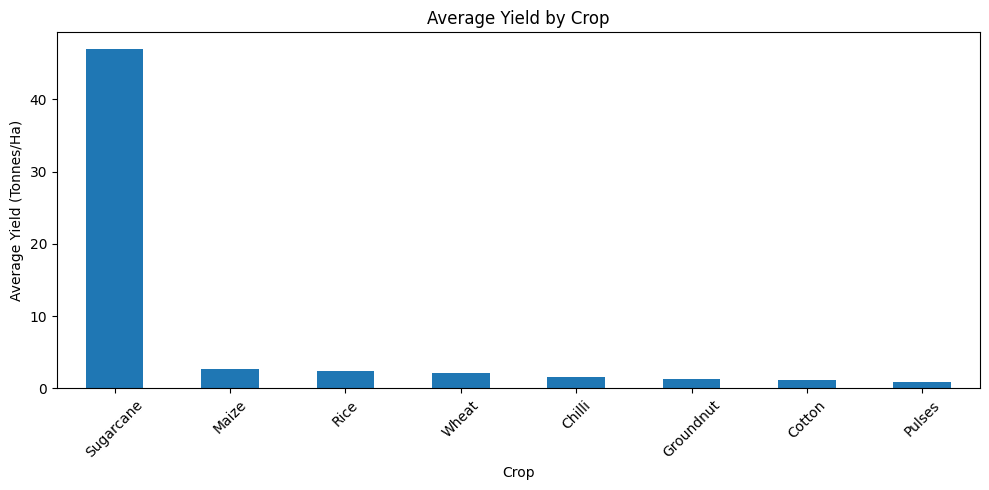

In [164]:
#  Average yield by crop

crop_yield = (
    df_clean.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

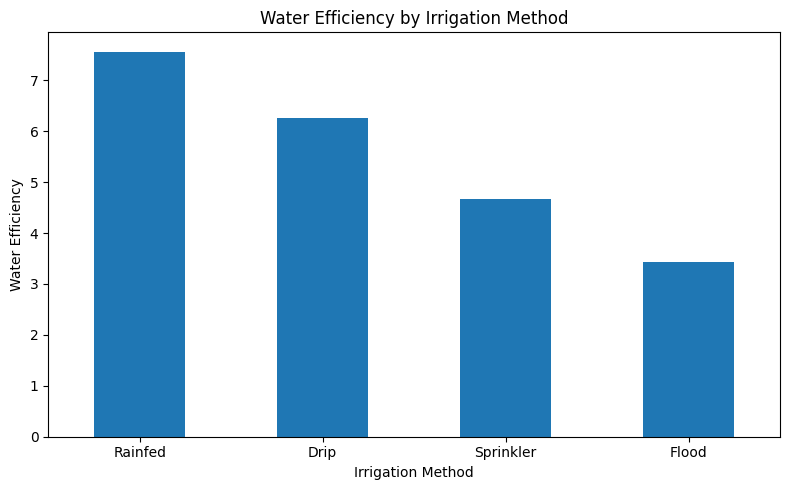

In [165]:
#  Water efficiency by irrigation method

irrigation_efficiency = (
    df_clean.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
irrigation_efficiency.plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

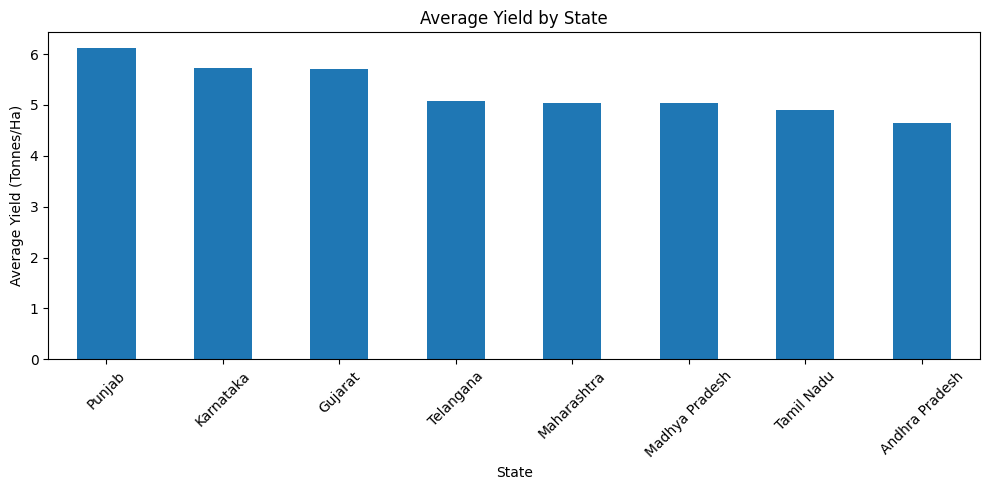

In [166]:
# Average yield by state

state_yield = (
    df_clean.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
state_yield.plot(kind="bar")

plt.title("Average Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

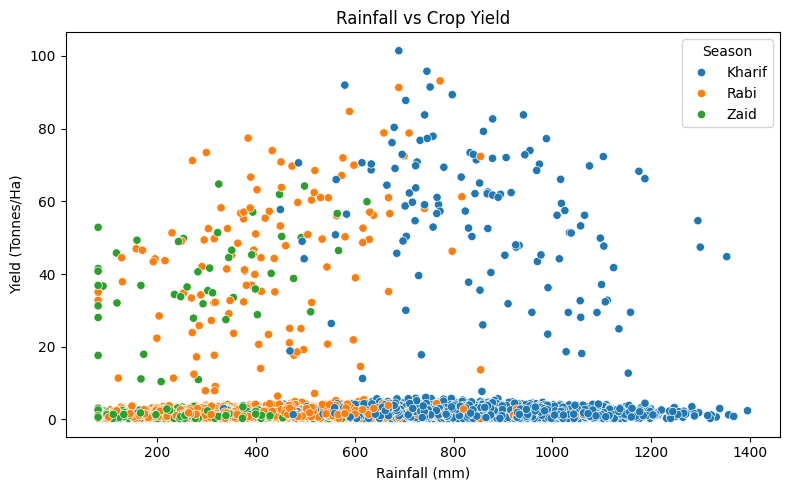

In [167]:
# Rainfall vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

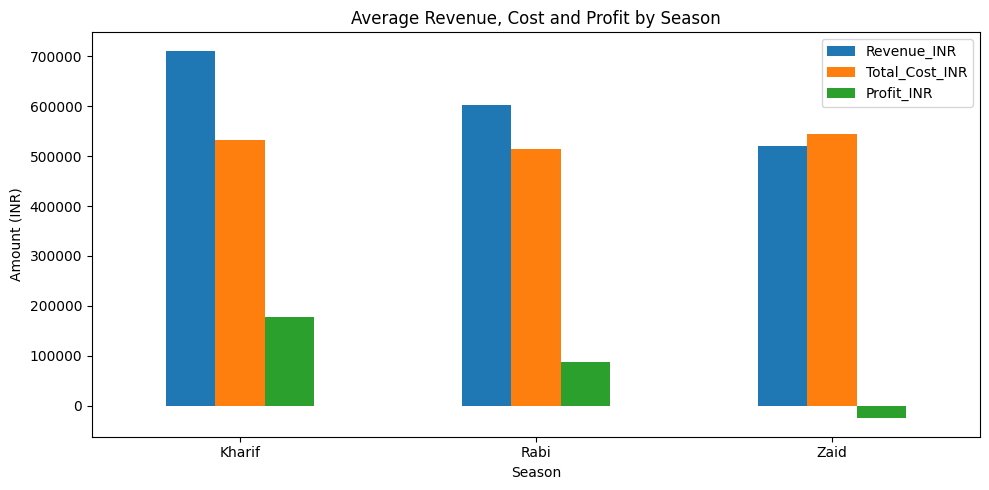

In [168]:
# Revenue, Cost and Profit by Season

economic_plot = (
    df_clean.groupby("Season")[
        ["Revenue_INR", "Total_Cost_INR", "Profit_INR"]
    ].mean()
)

economic_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Revenue, Cost and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

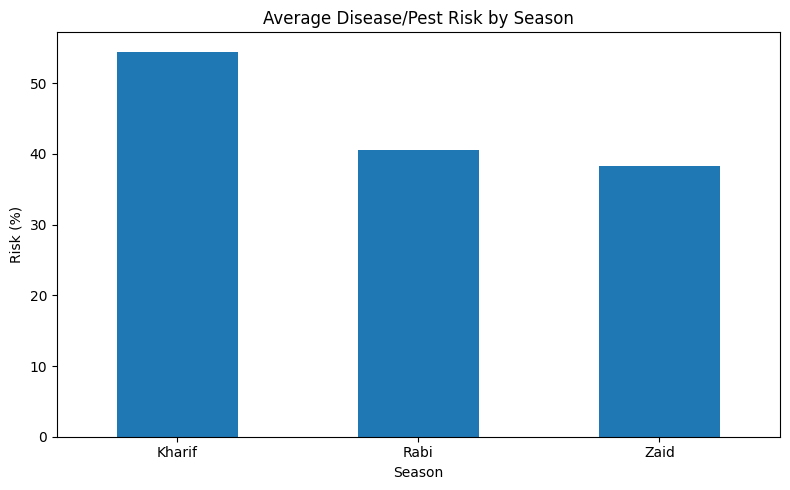

In [169]:
# Disease and pest risk by season

risk_by_season = (
    df_clean.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
risk_by_season.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [170]:
# Final dashboard summary table

dashboard_summary = pd.DataFrame({
    "Metric": [
        "Total Farms",
        "States Covered",
        "Crops Covered",
        "Average Yield",
        "Average Profit",
        "Best Season by Yield",
        "Best Crop by Yield",
        "Best Irrigation by Water Efficiency"
    ],

    "Value": [
        total_farms,
        total_states,
        total_crops,
        f"{average_yield:.2f} Tonnes/Ha",
        f"₹{average_profit:,.2f}",
        best_season,
        best_crop,
        best_irrigation
    ]
})

dashboard_summary

,Metric,Value
0,Total Farms,4000
1,States Covered,8
2,Crops Covered,8
3,Average Yield,5.27 Tonnes/Ha
4,Average Profit,"₹111,556.46"
5,Best Season by Yield,Kharif
6,Best Crop by Yield,Sugarcane
7,Best Irrigation by Water Efficiency,Rainfed
